# Visualizing the sequence → peak landscape

Figures for the peak-conditioned design work in this folder ([`in-silico-test/`](.)) — the same
landscape and pipeline shape as
`archive/esm2_design/visualization.ipynb` (archived), but with this
experiment's own models and split: a **nested** oracle-primary train/val/test split (not the
source pipeline's coordinated one) and a surrogate chosen by 3-fold cross-validation rather than a
single 70/15/15 split. Each section is one figure with its caption underneath, in the order they
would appear in a write-up.

1. **Landscape ruggedness** — the curated 758 laid out in sequence space, with excitation and
   emission raised into the third dimension so the map becomes a terrain. Static first, then the
   same two terrains as rotatable Plotly scenes.
2. **The same ruggedness, cluster by cluster** — k-means on the same embedding, and the
   emission peaks each sequence cluster — and each ancestral lineage — actually contains.
3. **The nested split** — how the surrogate's 85/15 split and its 3-fold CV nest entirely
   inside the oracle's training pool.
4. **Architecture sweep, surrogate** — a 48-way sweep on ESM-2, re-ranked by 3-fold CV against an
   NN floor.
5. **Architecture sweep, oracle** — the same sweep, run independently on ProstT5, single split.
6. **Test predictions, surrogate** — the CV-confirmed, train+val-refit surrogate on its held-out
   test set.
7. **Test predictions, oracle** — the sweep-selected oracle on its own held-out test set.
Sections 1-7 are task-independent: they are the landscape, the split and the two peak models, and
say nothing about any particular set of design tasks. **The design results live in
[`visualization_task2.ipynb`](visualization_task2.ipynb)** — task set 2, a random qualifying target
per scaffold, from [`2_design_task_specification/`](2_design_task_specification). The design figures for the earlier task set
1 (each scaffold paired with its *most spectrally distant* target) were Sections 8-9 here until
that task set was archived; they are unchanged in
[`archive/visualization_task1_design.ipynb`](archive/visualization_task1_design.ipynb).

Figures follow the **2026 Arcadia style guide**, matching
[`../dataset_pipeline/visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb):
Atkinson Hyperlegible Next for text, Atkinson Hyperlegible Mono for numerals, the Arcadia magma
gradient wherever a wavelength is shaded continuously, and charts titled in the caption rather
than in the figure.

> Run from `in-silico-test/`. The shared prerequisites live in `dataset_pipeline/` and are one-off:
> `python fetch_arcadia_fonts.py` (fonts, seconds) and
> `python embed_fpbase_maxpool.py` (embedding cache, a couple of minutes on GPU/MPS). This folder's
> own artifacts — `data/dual_splits.csv`, `trained_models/{surrogate,oracle}_sweep/`,
> `trained_models/surrogate_cv3.csv`, and `trained_models/surrogate_final/` — come from
> `make_dual_split.py`, `sweep_peak_oracle.py --role both --seeds 0`, `cv_all_surrogate.py`, and
> `train_final_surrogate.py` respectively, in that order.

In [1]:
# The inline backend crops to "tight" by default, which silently rescales every figure and
# throws away the guide's panel dimensions. Turn it off so a 1000px panel really is 1000px.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

import hashlib
import json
import os

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import arcadia_pycolor as apc

# Fonts and the curated/embedding caches are produced under dataset_pipeline/ and are shared,
# split-independent -- read from there unchanged. This experiment's own split and models are
# local (data/dual_splits.csv, trained_models/), see DUAL_SPLITS below.
DP = "../dataset_pipeline"
FONTS = f"{DP}/fonts"
apc.mpl.setup(font_dirpath=FONTS if os.path.isdir(FONTS) else None)
if not os.path.isdir(FONTS):
    print("NOTE: run `python fetch_arcadia_fonts.py` in dataset_pipeline/ for the Atkinson faces")

# apc sets figure.dpi to 72 so that one point equals one style-guide pixel. Keep that
# correspondence for layout, but render at 2x so the inline PNGs are not soft on screen.
plt.rcParams["figure.dpi"] = 144
RNG_SEED = 0

PROT_JSON = f"{DP}/../fpbase-extractor/fpbase_output/fpbase_proteins.json"
EMB_NPY = f"{DP}/data/fpbase_esm2_650M_max.npy"
EMB_META = f"{DP}/data/fpbase_esm2_650M_max.meta.json"
CURATED = f"{DP}/data/peak/curated"
DUAL_SPLITS = "data/dual_splits.csv"   # this experiment's own nested split, NOT dataset_pipeline's
FIGDIR = "figures"                     # this folder's own figures, as in the sibling notebooks

assert os.path.exists(EMB_NPY), "run `python embed_fpbase_maxpool.py` in dataset_pipeline/ first"
os.makedirs(FIGDIR, exist_ok=True)
print("environment ready")

environment ready


### Style-guide helpers

The same helpers the curation notebook uses. Panel geometry is expressed in the guide's pixels
(Full_wide 1000, Float 650), and since `arcadia_pycolor` pins the figure DPI to 72, one matplotlib
point is exactly one style-guide pixel.

One departure: excitation and emission are shaded on a **single shared** magma normalization
spanning both, rather than each panel getting its own scale. A given colour therefore means the
same wavelength in both panels, and the two terrains can be read against each other.

In [2]:
PX = 1 / 72                       # one style-guide pixel, expressed in inches
FULL_WIDE, FLOAT, HALF_SQUARE = 1000, 650, 490

# Text roles, straight from the guide's "Text styles" page
PANEL_LETTER = dict(fontsize=38, fontweight="regular", color=str(apc.chateau))
ANNOTATION = dict(fontsize=15, fontweight="ultralight", color=str(apc.charcoal))
NUMBER_NOTE = dict(fontfamily="Atkinson Hyperlegible Mono", fontsize=14.5,
                   color=str(apc.charcoal))

HIGHLIGHT, CONTRAST = str(apc.aegean), str(apc.amber)
# A third data colour, for the one series that is neither of the two conditions: the unguided
# control arm of Sections 8-9, which has to read as the same series on both sides of a figure.
CONTROL = str(apc.aster)
NEUTRAL, NEUTRAL_SOFT = str(apc.chateau), str(apc.taupe)

# Continuous scale for wavelength. Magma is Arcadia's default gradient; its cool-to-warm run keeps
# short and long wavelengths reading the intuitive way round. The very top of the ramp is dropped
# because it approaches the page white and would make the reddest proteins disappear.
PEAK_CMAP = LinearSegmentedColormap.from_list(
    "apc:magma_dots", apc.gradients.magma.to_mpl_cmap()(np.linspace(0.04, 0.86, 256))
)


def panel_letter(ax, letter, dx=-46, dy=12):
    """Place a panel letter at the top-left corner of a 2-D axes, in the guide's style."""
    ax.annotate(letter, xy=(0, 1), xycoords="axes fraction",
                xytext=(dx, dy), textcoords="offset points",
                ha="left", va="bottom", annotation_clip=False, **PANEL_LETTER)


def panel_letter_3d(ax, letter, x=0.02, y=0.84):
    """Panel letter on a 3-D axes.

    Axes3D has no annotate in axes coordinates, so use text2D. A 3-D axes also insets its drawn
    cube well within its own bbox, so the letter sits lower than the 2-D convention would put it,
    which keeps it beside the plot rather than adrift in the margin.
    """
    ax.text2D(x, y, letter, transform=ax.transAxes, ha="left", va="bottom", **PANEL_LETTER)

## 1. Landscape ruggedness

### 1.1 Rebuild the curation notebook's sequence-space map

The layout is taken from Figure 1 of
[`visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb) and is reproduced here
**exactly**: the same max-pooled ESM-2 embedding of all 990 sequenced FPbase proteins, standardized,
compressed to 50 principal components, then t-SNE with `init="pca"`, perplexity 30 and
`random_state=0`.

The fit deliberately stays on all 990. Dropping the excluded proteins *before* the fit would move
every surviving point, because t-SNE's layout depends on the whole neighbour graph; keeping them in
and discarding their coordinates afterwards means each of the 758 sits precisely where the curation
figure put it. So this is a subset of that map, not a new one.

Membership is matched **on the sequence** rather than the slug, since stage C of the pipeline
collapses each group of identical sequences to one representative row and slug matching would miss
the duplicates that were folded away.

In [3]:
proteins = json.load(open(PROT_JSON))
meta = json.load(open(EMB_META))

prot = pd.DataFrame([
    {
        "slug": p.get("slug", ""),
        "name": p.get("name", ""),
        "organism": p.get("parent_organism") or "",
        "seq": (p.get("seq") or "").strip().upper(),
    }
    for p in proteins
    if (p.get("seq") or "").strip()
])

# embed_fpbase_maxpool.py records an md5 over the exact sequence list it embedded; rebuilding the
# same list here and checking it guarantees each embedding row still lines up with a row of prot.
md5 = hashlib.md5("\x00".join(prot.seq).encode()).hexdigest()
assert md5 == meta["seq_md5"], "embedding cache is stale -- rerun embed_fpbase_maxpool.py"

Z = np.load(EMB_NPY)
assert len(Z) == len(prot)

curated = pd.read_csv(f"{CURATED}/peaks_assignments.csv").sort_values("index").reset_index(drop=True)
prot["is_true_fp"] = prot.seq.isin(set(curated.seq))

print(f"{len(proteins)} FPbase entries | {len(prot)} with a sequence | "
      f"embedding {Z.shape} ({meta['model']}, layer {meta['layer']}, {meta['pooling']}-pooled)")
print(f"curated peak set: {len(curated)} rows, {prot.is_true_fp.sum()} of the {len(prot)} "
      f"sequenced proteins map into it")

1041 FPbase entries | 990 with a sequence | embedding (990, 1280) (esm2_t33_650M_UR50D, layer 33, max-pooled)
curated peak set: 758 rows, 758 of the 990 sequenced proteins map into it


In [4]:
Zstd = StandardScaler().fit_transform(Z)
pca50 = PCA(n_components=50, random_state=RNG_SEED)
Z50 = pca50.fit_transform(Zstd)
print(f"50-PC embedding: {Z50.shape} ({pca50.explained_variance_ratio_.sum():.1%} variance retained)")

xy = TSNE(n_components=2, metric="euclidean", init="pca", perplexity=30,
          learning_rate="auto", random_state=RNG_SEED).fit_transform(Z50)
prot["x"], prot["y"] = xy[:, 0], xy[:, 1]

# Keep only the curated rows, in peaks.npy order, so x/y/ex/em stay index-aligned with the
# rest of the pipeline (dual_splits.csv, the embedding caches, peaks_assignments.csv).
seq_to_row = {s: i for i, s in enumerate(prot.seq)}
rows = curated.seq.map(seq_to_row)
assert rows.notna().all(), "every curated sequence should be in the embedding table"
rows = rows.astype(int).to_numpy()
assert len(set(rows)) == len(rows) == len(curated), "curated rows must map one-to-one"

x, y = prot.x.to_numpy()[rows], prot.y.to_numpy()[rows]
ex = curated.ex_max.to_numpy(float)
em = curated.em_max.to_numpy(float)
names = curated.name.to_numpy()

print(f"t-SNE fitted on all {len(prot)}, kept the {len(x)} curated")
print(f"excitation {ex.min():.0f}-{ex.max():.0f} nm | emission {em.min():.0f}-{em.max():.0f} nm")

50-PC embedding: (990, 50) (84.3% variance retained)


t-SNE fitted on all 990, kept the 758 curated
excitation 343-611 nm | emission 414-684 nm


### 1.2 Turn the point cloud into a terrain

With the map as the ground plane, each protein's peak becomes a height, and the 758 points become
a surface over Delaunay triangles of the t-SNE coordinates.

Delaunay triangulates the *convex hull*, so it happily spans the empty gaps between clusters and
would draw sheer walls where there is simply no data. Every triangle whose longest edge exceeds the
90th percentile is therefore masked out. The threshold is a heuristic and it is the one dial in the
figure: raising it bridges more gaps with invented surface, lowering it fragments real
neighbourhoods. It is reported below so the choice stays visible.

Relief is not smoothed. Interpolating or averaging the heights would flatten exactly the feature
this figure exists to show, so neighbouring sequences with very different peaks stay as the near
vertical faces they are.

In [5]:
EDGE_PCTL = 90                    # drop triangles whose longest edge is above this percentile

tri_all = mtri.Triangulation(x, y)
t = tri_all.triangles
# longest side of each triangle, from the three (vertex, next vertex) pairs
edge_len = np.sqrt((x[t] - x[np.roll(t, 1, axis=1)]) ** 2
                   + (y[t] - y[np.roll(t, 1, axis=1)]) ** 2).max(axis=1)
edge_cut = np.percentile(edge_len, EDGE_PCTL)

surf = mtri.Triangulation(x, y)
surf.set_mask(edge_len > edge_cut)

# One scale for both panels so a colour and a height mean the same thing in each.
PEAK_NORM = Normalize(vmin=min(ex.min(), em.min()), vmax=max(ex.max(), em.max()))
ZLIM = (PEAK_NORM.vmin - 10, PEAK_NORM.vmax + 10)


def robust_lims(v, pad=0.04):
    """Axis limits covering the bulk, so a few stray points cannot shrink the terrain."""
    lo, hi = np.percentile(v, [1, 99])
    margin = (hi - lo) * pad
    return lo - margin, hi + margin


XLIM, YLIM = robust_lims(x), robust_lims(y)

print(f"{len(t)} Delaunay triangles | longest edge <= {edge_cut:.1f} keeps "
      f"{(~surf.mask).sum()} ({(~surf.mask).mean():.0%})")
print(f"shared height scale: {PEAK_NORM.vmin:.0f}-{PEAK_NORM.vmax:.0f} nm")

1504 Delaunay triangles | longest edge <= 8.9 keeps 1353 (90%)
shared height scale: 343-684 nm


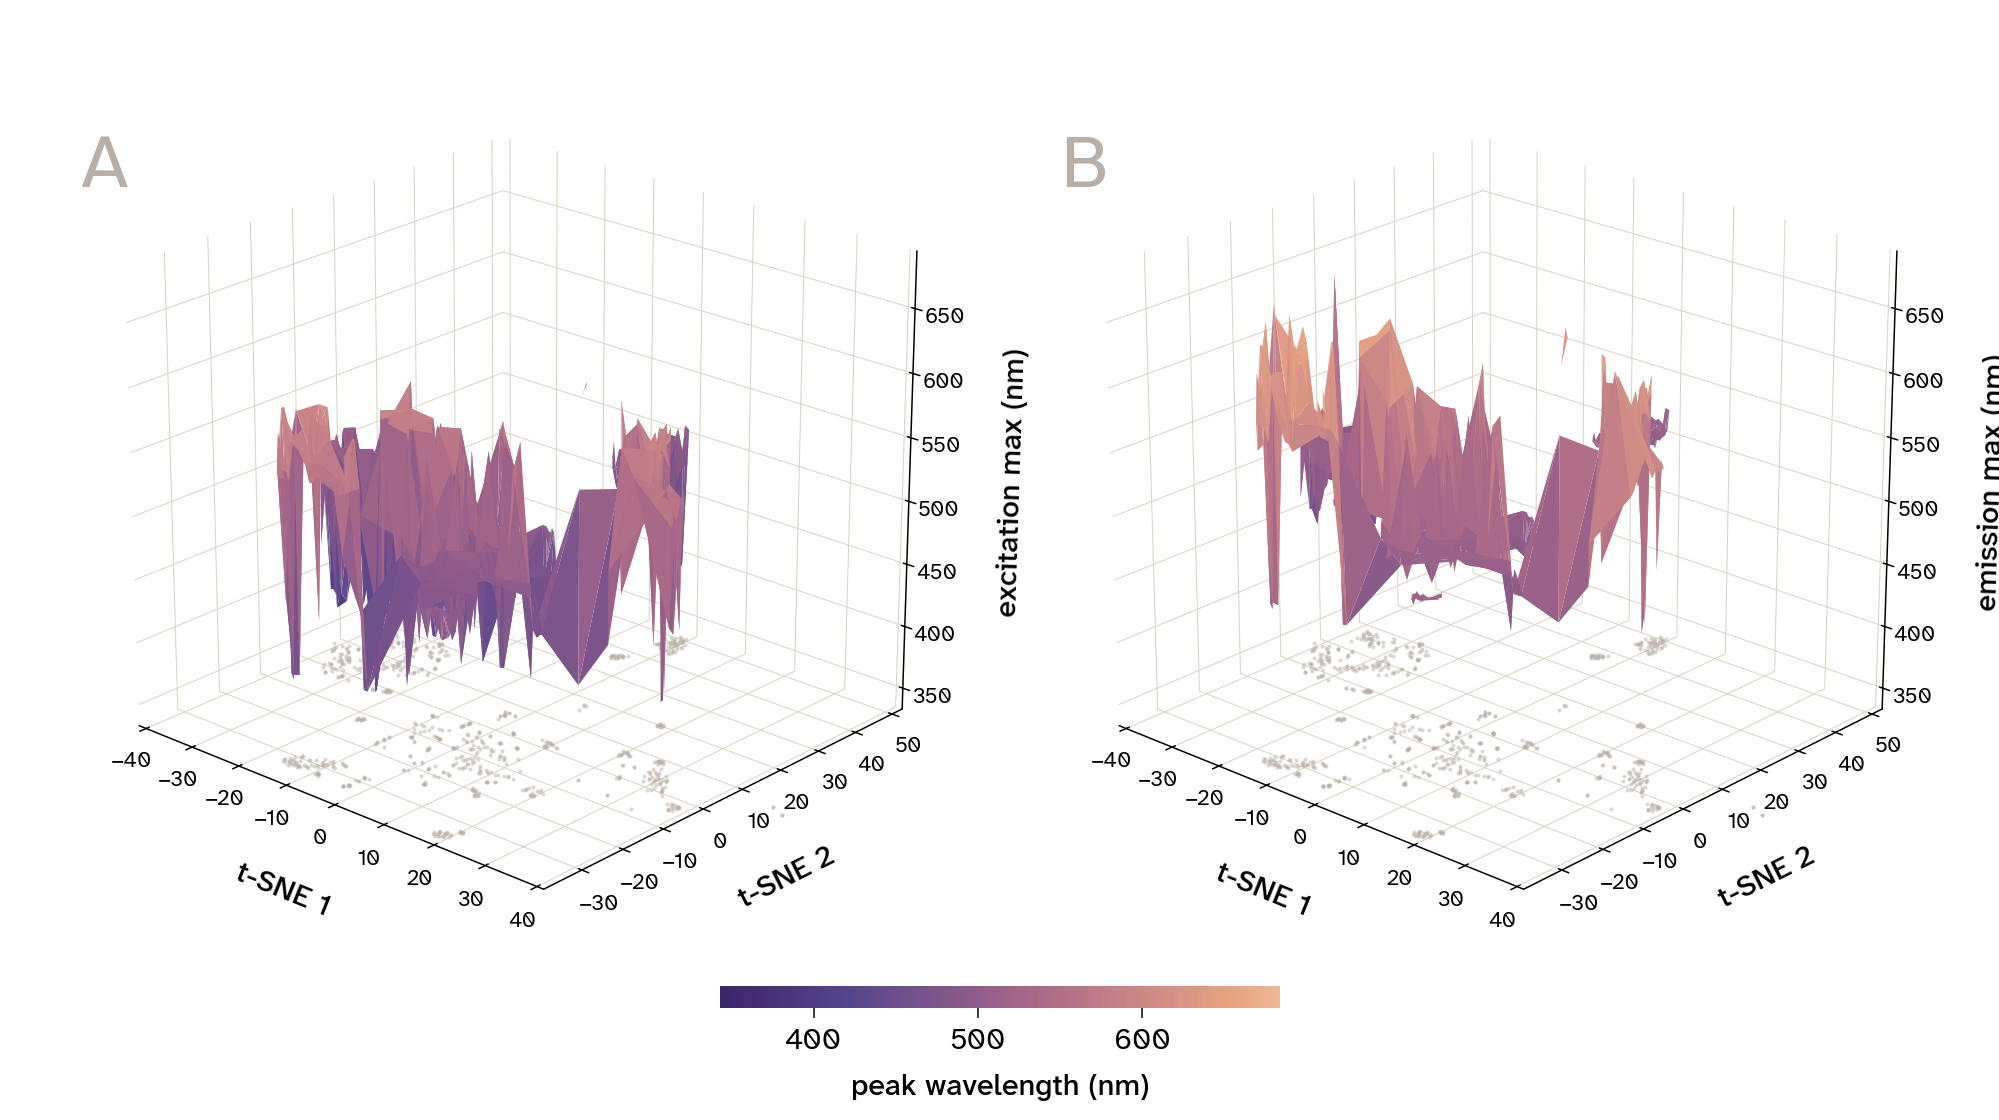

2103 edges in the drawn mesh
  |dex| median  18 nm   p90 102 nm
  |dem| median  10 nm   p90  74 nm
  0.5(|dex|+|dem|): median 16.5 nm | 39% under 10 nm | 23% over 50 nm | max 218 nm

steepest faces in the terrain:
    218 nm   mNeptune684            (604, 684)   vs   mTagBFP2               (399, 454)
    216 nm   mNeptune684            (604, 684)   vs   secBFP2                (399, 456)
    212 nm   mCarmine               (603, 675)   vs   mTagBFP2               (399, 454)
    206 nm   Electra1               (402, 454)   vs   mGarnet2               (598, 671)
    206 nm   Electra2               (403, 454)   vs   mGarnet2               (598, 671)


In [6]:
ELEV, AZIM = 22, -48              # low enough that the cliff faces are seen edge-on
FIG_H = 560

fig = plt.figure(figsize=(FULL_WIDE * PX, FIG_H * PX))
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.15, top=0.95, wspace=0.0)

for i, (z, what, letter) in enumerate([(ex, "excitation", "A"), (em, "emission", "B")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")

    # the t-SNE map itself, dropped onto the floor so the terrain keeps its footprint
    ax.scatter(x, y, zs=ZLIM[0], zdir="z", s=4, c=NEUTRAL, alpha=0.5, depthshade=False)
    ax.plot_trisurf(surf, z, cmap=PEAK_CMAP, norm=PEAK_NORM,
                    linewidth=0, edgecolor="none", antialiased=True)

    ax.set(xlim=XLIM, ylim=YLIM, zlim=ZLIM,
           xlabel="t-SNE 1", ylabel="t-SNE 2", zlabel=f"{what} max (nm)")
    ax.set_box_aspect((1, 1, 0.9))
    ax.view_init(elev=ELEV, azim=AZIM)
    # the guide's 0.75pt rules; Axes3D panes are drawn instead of spines
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor("white")
        axis.pane.set_edgecolor(NEUTRAL_SOFT)
        axis.pane.set_alpha(1.0)
        axis._axinfo["grid"].update(color=NEUTRAL_SOFT, linewidth=0.5)
    ax.tick_params(labelsize=11, pad=1)
    panel_letter_3d(ax, letter)

# One shared colourbar: the height scale is common to both panels, so one key serves them both.
cax = fig.add_axes([0.36, 0.10, 0.28, 0.020])
bar = fig.colorbar(plt.cm.ScalarMappable(norm=PEAK_NORM, cmap=PEAK_CMAP),
                   cax=cax, orientation="horizontal")
bar.set_label("peak wavelength (nm)")
bar.outline.set_visible(False)
apc.mpl.set_colorbar_ticklabel_monospaced(cax)

fig.savefig(f"{FIGDIR}/landscape_ruggedness_tsne.svg")
fig.savefig(f"{FIGDIR}/landscape_ruggedness_tsne.png", dpi=200)
plt.show()

# Relief along the drawn mesh: how far the peaks move between two proteins the surface joins.
# This is the terrain's steepness expressed as a number, over the same edges the eye is reading.
kept = surf.triangles[~surf.mask]
sides = np.concatenate([kept[:, [0, 1]], kept[:, [1, 2]], kept[:, [2, 0]]])
pairs = np.unique(np.sort(sides, axis=1), axis=0)      # each shared side counted once
i, j = pairs[:, 0], pairs[:, 1]
d_ex, d_em = np.abs(ex[i] - ex[j]), np.abs(em[i] - em[j])
d_peak = 0.5 * (d_ex + d_em)

print(f"{len(pairs)} edges in the drawn mesh")
print(f"  |dex| median {np.median(d_ex):3.0f} nm   p90 {np.percentile(d_ex, 90):3.0f} nm")
print(f"  |dem| median {np.median(d_em):3.0f} nm   p90 {np.percentile(d_em, 90):3.0f} nm")
print(f"  0.5(|dex|+|dem|): median {np.median(d_peak):.1f} nm | "
      f"{100 * np.mean(d_peak < 10):.0f}% under 10 nm | {100 * np.mean(d_peak > 50):.0f}% over 50 nm | "
      f"max {d_peak.max():.0f} nm")
print("\nsteepest faces in the terrain:")
for k in np.argsort(-d_peak)[:5]:
    print(f"  {d_peak[k]:5.0f} nm   {names[i[k]][:22]:22} ({ex[i[k]]:.0f}, {em[i[k]]:.0f})"
          f"   vs   {names[j[k]][:22]:22} ({ex[j[k]]:.0f}, {em[j[k]]:.0f})")

**Figure 1. The sequence → peak map is a rugged terrain, not a smooth surface.** The 758 curated
proteins placed at their coordinates in the Figure-1 t-SNE of
[`visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb) (max-pooled ESM-2,
standardize → PCA-50 → t-SNE, perplexity 30, fitted on all 990 sequenced FPbase proteins), with
**(A)** excitation and **(B)** emission maximum as height. The surface is the Delaunay
triangulation of the map, with the longest tenth of triangles removed so no sheet is drawn across
empty space; grey dots on the floor mark every protein, including those the mask leaves uncovered.
Both panels share one height scale and one colour scale, so A and B can be read against each other.

The terrain is the argument. If sequence neighbourhood determined colour, this would be a set of
gently sloping plateaus; instead broad flats are cut by near-vertical faces, and the drop is often
the full height of the axis. Along the edges the surface actually draws, the two peaks move by a
median of only 16.5 nm — but 23% of those edges span more than 50 nm and the steepest reach 218 nm.
The mesh is roughly two-fifths flat and half cliff.

The steepest faces are not exotic pairings. `mNeptune684` (604, 684 nm) sits beside `mTagBFP2`
(399, 454 nm), a 218 nm drop; `mGarnet2` sits beside `Electra1`. In fact all five of the steepest
faces printed above are between proteins whose `parent_organism` is *Entacmaea quadricolor* — every
one an engineered descendant of the same eqFP578 ancestor, adjacent in embedding space, at opposite
ends of the visible spectrum. The cliffs are not gaps between distant families; they are inside a
single lineage.

This is the geometry behind the honest-split result in `cluster_split/`. A model
that interpolates smoothly across sequence space must fall off these faces, which is why
extrapolation error to unseen lineages (~27–30 nm) runs roughly double the random-split figure.

Panel A is visibly rougher than panel B, and the numbers agree: excitation moves by a median 18 nm
between mesh neighbours against emission's 10 nm, with a 90th percentile of 102 nm against 74 nm.
Excitation is the harder of the two peaks to predict from sequence neighbourhood alone.

Two caveats. t-SNE distances are **not** quantitative — cluster sizes and the gaps between them
carry no meaning, and the axes have no fixed orientation, so read horizontal position as "what
groups with what" and nothing more. And the surface is an artefact of the triangulation, not a
measurement: only the vertices are data.

### 1.3 The same two terrains, interactive

A fixed camera is a poor way to read relief: whichever angle is chosen, some cliffs are face-on and
others hide behind the ridge in front of them. The cells below rebuild both panels as rotatable
Plotly scenes from exactly the same triangulation, height scale and colour scale, so nothing about
the data changes — only the ability to move the camera.

Drag to rotate, scroll to zoom, and **hover any vertex to identify the protein**, which is the part
the static figure cannot do: the spikes stop being anonymous and become named FPs with their peaks
and ancestral organism attached. Hovering along the edge of any cliff is the quickest way to see
the *Entacmaea* pattern noted in the caption above for yourself.

Each scene is also written to a standalone HTML file in `figures/`, openable in a browser without
Jupyter. Section 1.2's static SVG remains the version to put in a write-up.

In [7]:
import plotly.graph_objects as go

# Plotly wants an explicit list of colour stops, so sample the same magma ramp the static
# figure uses. 32 stops is past the point where banding is visible.
PEAK_COLORSCALE = [
    [s, f"rgb({int(255 * r)},{int(255 * g)},{int(255 * b)})"]
    for s, (r, g, b, _) in zip(np.linspace(0, 1, 32), PEAK_CMAP(np.linspace(0, 1, 32)))
]

organisms = curated.parent_organism.fillna("unrecorded").to_numpy()
kept_tri = surf.triangles[~surf.mask]              # the same faces the static figure draws


def ruggedness_scene(z, what, height=640):
    """One rotatable terrain: masked Delaunay mesh + hoverable vertices + the map on the floor."""
    hover = np.stack([names, organisms, ex, em], axis=1)
    fig = go.Figure()

    # The mesh carries the surface; hovering it would report triangle interiors rather than
    # proteins, so identification is left to the vertex layer below.
    fig.add_trace(go.Mesh3d(
        x=x, y=y, z=z,
        i=kept_tri[:, 0], j=kept_tri[:, 1], k=kept_tri[:, 2],
        intensity=z, colorscale=PEAK_COLORSCALE,
        cmin=PEAK_NORM.vmin, cmax=PEAK_NORM.vmax,
        flatshading=True, hoverinfo="skip", showscale=True,
        colorbar=dict(title=dict(text="peak (nm)", side="right"), thickness=14, len=0.55),
        lighting=dict(ambient=0.62, diffuse=0.85, specular=0.12, roughness=0.9),
        lightposition=dict(x=100, y=-200, z=400),
    ))

    # Vertices are the only real data points, so they carry the hover.
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z, mode="markers",
        marker=dict(size=2, color="rgba(20,20,20,0.55)"),
        customdata=hover,
        hovertemplate=("<b>%{customdata[0]}</b><br>%{customdata[1]}"
                       "<br>ex %{customdata[2]:.0f} nm · em %{customdata[3]:.0f} nm"
                       "<extra></extra>"),
        showlegend=False,
    ))

    # Footprint of the map, including the proteins the edge mask leaves uncovered.
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=np.full_like(z, ZLIM[0]), mode="markers",
        marker=dict(size=1.6, color=NEUTRAL, opacity=0.5),
        hoverinfo="skip", showlegend=False,
    ))

    fig.update_layout(
        template="plotly_white", width=900, height=height,
        margin=dict(l=0, r=0, t=28, b=0),
        title=dict(text=f"{what} max over the sequence-space map", x=0.02, font=dict(size=15)),
        scene=dict(
            xaxis=dict(title="t-SNE 1", range=list(XLIM), backgroundcolor="white",
                       gridcolor=NEUTRAL_SOFT, zeroline=False),
            yaxis=dict(title="t-SNE 2", range=list(YLIM), backgroundcolor="white",
                       gridcolor=NEUTRAL_SOFT, zeroline=False),
            zaxis=dict(title=f"{what} max (nm)", range=list(ZLIM), backgroundcolor="white",
                       gridcolor=NEUTRAL_SOFT, zeroline=False),
            aspectratio=dict(x=1, y=1, z=0.9),          # matches the static set_box_aspect
            camera=dict(eye=dict(x=1.36, y=-1.52, z=0.83)),   # ~ elev 22, azim -48
        ),
    )
    return fig


scenes = {"excitation": ruggedness_scene(ex, "Excitation"),
          "emission": ruggedness_scene(em, "Emission")}
for what, fig in scenes.items():
    path = f"{FIGDIR}/landscape_ruggedness_{what}.html"
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    print(f"wrote {path}")

wrote figures/landscape_ruggedness_excitation.html
wrote figures/landscape_ruggedness_emission.html


In [8]:
scenes["excitation"].show()

In [9]:
scenes["emission"].show()

## 2. The same ruggedness, cluster by cluster

Figure 1 reads the landscape as a surface. The blunter question is whether sequence space carves
into *groups* whose colour is settled by membership alone: cluster the proteins on sequence and
sequence only, then look at what emission peaks each cluster actually contains.

The clustering runs in the same representation the map is built from — the standardized max-pooled
ESM-2 embedding compressed to 50 principal components (fitted on all 990 sequenced proteins,
Section 1.1) — with k-means fitted on the 758 curated rows, so every cluster's distribution is over
its own members. Nothing about the peaks enters the clustering.

Section 2.1 settles how many clusters to use and shows that the answer barely matters, Section 2.2
is the figure itself, and Section 2.3 repeats the exercise with FPbase's own ancestral lineages in
place of the algorithm's clusters. The clusters that come out are recognisable lineages — *Aequorea* GFP,
*Discosoma* DsRed, *Entacmaea* eqFP611 reds, and two mixed coral groups — which is what makes their
emission ranges worth reading.

### 2.1 How many clusters?

k-means needs k chosen up front, so the sweep below runs k = 2-20 and records four things per k:
how much of the *embedding's* variance the partition removes (1 - inertia/total sum of squares, the
usual elbow curve), how much of the *emission* variance it removes, the silhouette score, and the
size of every cluster it produces.

In [10]:
from collections import Counter

from scipy.stats import gaussian_kde
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

K_RANGE = range(2, 21)
NCLUST = 8               # justified by the sweep below, then used for the rest of the section
MIN_KDE = 10             # a KDE over fewer points would be an invention, not a summary
DOM_SHARE = 0.6          # name a cluster for a genus only if that genus holds this much of it
Zc = Z50[rows]           # the curated 758, in the same 50-PC space Section 1.1's map came from


def pooled_within_sd(v, labels):
    """SD of v about its own cluster's mean, pooled across clusters -- the spread k-means leaves behind."""
    num, den = 0.0, 0
    for c in np.unique(labels):
        m = labels == c
        if m.sum() > 1:
            num += ((v[m] - v[m].mean()) ** 2).sum()
            den += m.sum() - 1
    return np.sqrt(num / den)


em_sd = em.std(ddof=1)
SS_TOTAL = ((Zc - Zc.mean(0)) ** 2).sum()      # k-means inertia at k=1, i.e. all of the variance
print(f"emission SD across all {len(em)} curated proteins: {em_sd:.1f} nm")
print("      embedding  emission            smallest  largest")
print("  k    var expl  var expl  within SD   cluster  cluster  silhouette")
ksweep = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=50, random_state=RNG_SEED).fit(Zc)
    sizes = np.bincount(km.labels_)
    w = pooled_within_sd(em, km.labels_)
    ksweep.append(dict(k=k, sizes=sizes, within_sd=w, sil=silhouette_score(Zc, km.labels_),
                       seq_var=1 - km.inertia_ / SS_TOTAL, em_var=1 - (w / em_sd) ** 2))
    r = ksweep[-1]
    print(f" {k:2d}      {r['seq_var']:5.2f}     {r['em_var']:5.2f}   {w:5.1f} nm     "
          f"{sizes.min():4d}     {sizes.max():4d}      {r['sil']:.3f}")

emission SD across all 758 curated proteins: 52.0 nm
      embedding  emission            smallest  largest
  k    var expl  var expl  within SD   cluster  cluster  silhouette
  2       0.17      0.20    46.5 nm      279      479      0.192


  3       0.28      0.20    46.4 nm       18      462      0.216
  4       0.35      0.20    46.5 nm       11      297      0.209


  5       0.43      0.20    46.5 nm        4      284      0.218
  6       0.50      0.21    46.3 nm        4      265      0.267


  7       0.54      0.34    42.3 nm        4      252      0.281


  8       0.57      0.50    36.8 nm        4      199      0.293


...

 16       0.69      0.51    36.3 nm        2      104      0.268


 17       0.70      0.55    35.0 nm        2      131      0.286


 18       0.72      0.53    35.8 nm        2      181      0.339


 19       0.73      0.53    35.6 nm        2       99      0.306


 20       0.74      0.53    35.8 nm        2       95      0.301


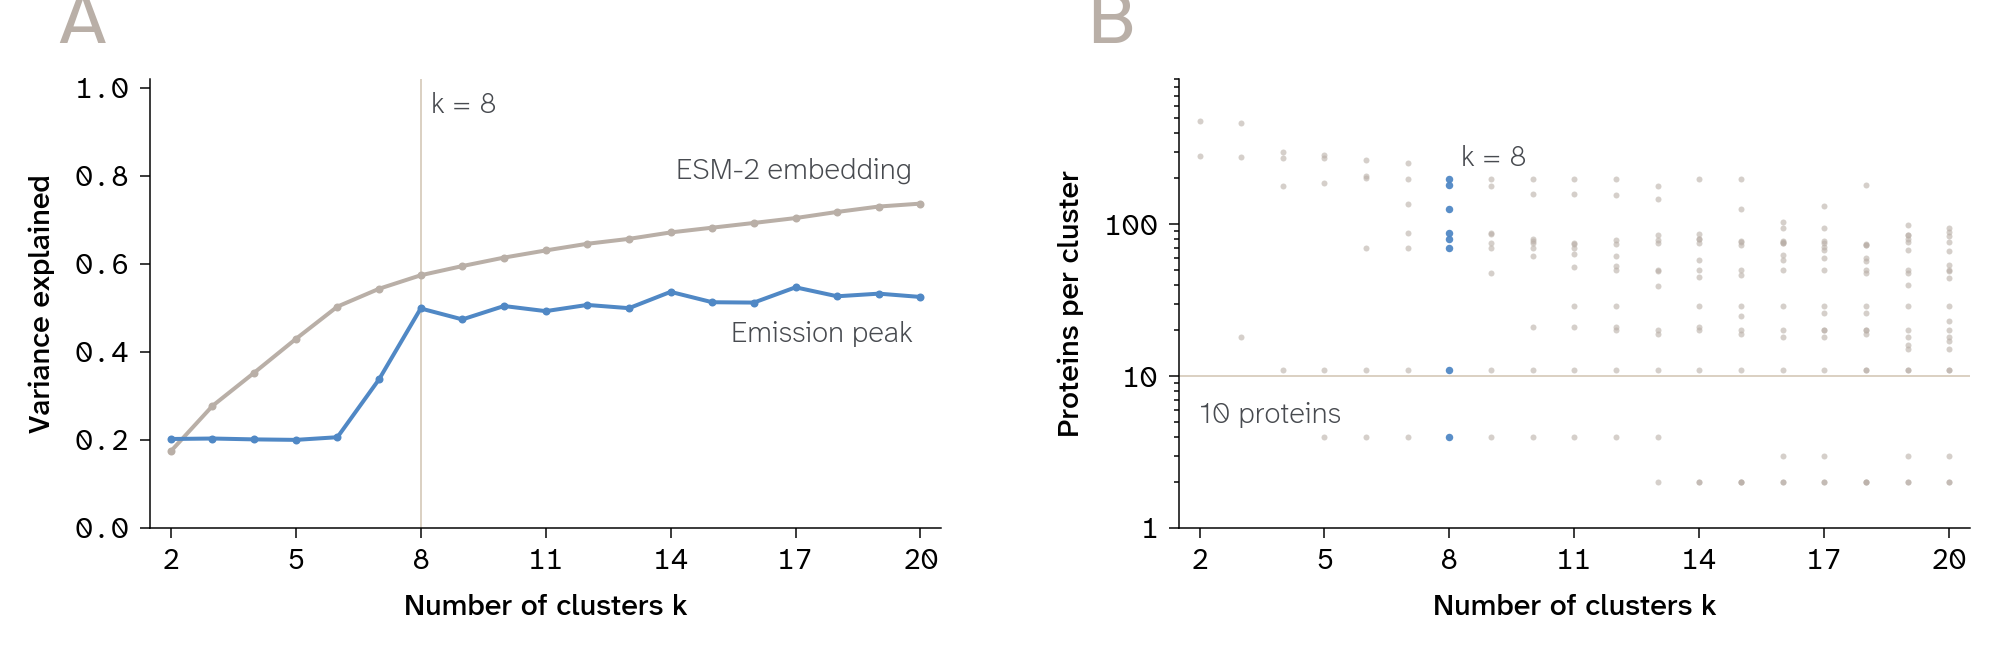

In [11]:
# Two panels, one question each: is k=8 enough (A), and does it leave clusters big enough to read a
# distribution from (B). The emission curve is the one that matters here, so it takes HIGHLIGHT and
# the embedding's own variance recedes into a neutral tone.
ks = [r["k"] for r in ksweep]
by_k = {r["k"]: r for r in ksweep}

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDE * PX, 330 * PX))
fig.subplots_adjust(left=0.075, right=0.985, bottom=0.20, top=0.88, wspace=0.30)

ax = axes[0]
ax.axvline(NCLUST, color=NEUTRAL_SOFT, lw=1.0, zorder=0)
ax.plot(ks, [r["seq_var"] for r in ksweep], color=NEUTRAL, lw=2, marker="o", ms=4, zorder=2)
ax.plot(ks, [r["em_var"] for r in ksweep], color=HIGHLIGHT, lw=2, marker="o", ms=4, zorder=3)
ax.annotate("ESM-2 embedding", xy=(ks[-1], ksweep[-1]["seq_var"]), xytext=(-4, 10),
            textcoords="offset points", ha="right", va="bottom", **ANNOTATION)
ax.annotate("Emission peak", xy=(ks[-1], ksweep[-1]["em_var"]), xytext=(-4, -12),
            textcoords="offset points", ha="right", va="top", **ANNOTATION)
ax.annotate(f"k = {NCLUST}", xy=(NCLUST, 1.0), xytext=(5, -2), textcoords="offset points",
            ha="left", va="top", **ANNOTATION)
ax.set(xlim=(ks[0] - 0.5, ks[-1] + 0.5), ylim=(0, 1.02), xticks=range(2, 21, 3),
       xlabel="Number of clusters k", ylabel="Variance explained")
apc.mpl.style_plot(ax, monospaced_axes="both")
panel_letter(ax, "A")

ax = axes[1]
ax.axhline(MIN_KDE, color=NEUTRAL_SOFT, lw=1.0, zorder=0)
for r in ksweep:
    chosen = r["k"] == NCLUST
    ax.scatter(np.full(r["k"], r["k"]), np.sort(r["sizes"]), s=14 if chosen else 9,
               color=HIGHLIGHT if chosen else NEUTRAL, alpha=0.95 if chosen else 0.6, lw=0,
               zorder=3 if chosen else 2)
ax.annotate(f"k = {NCLUST}", xy=(NCLUST, by_k[NCLUST]["sizes"].max()), xytext=(6, 4),
            textcoords="offset points", ha="left", va="bottom", **ANNOTATION)
ax.annotate(f"{MIN_KDE} proteins", xy=(ks[0], MIN_KDE), xytext=(0, -13),
            textcoords="offset points", ha="left", va="top", **ANNOTATION)
ax.set(yscale="log", xlim=(ks[0] - 0.5, ks[-1] + 0.5), ylim=(1.2, 900),
       xticks=range(2, 21, 3), yticks=[1, 10, 100],
       xlabel="Number of clusters k", ylabel="Proteins per cluster")
ax.set_yticklabels(["1", "10", "100"])
apc.mpl.style_plot(ax, monospaced_axes="both")
panel_letter(ax, "B")

fig.savefig(f"{FIGDIR}/landscape_cluster_k_choice.svg")
fig.savefig(f"{FIGDIR}/landscape_cluster_k_choice.png", dpi=200)
plt.show()

**Supporting figure for Figure 2. Eight clusters is where emission stops caring about k — and the
ceiling it stops at is only half the variance.** k-means on the 50-PC max-pooled ESM-2 embedding of
the 758 curated proteins, swept over k = 2-20 (one fit per k, `n_init=50`, seed 0). **(A)** Fraction
of variance the partition removes, in the embedding itself (grey, 1 - inertia/total SS) and in
emission peak (blue, 1 - within-cluster SD² / total SD²). The embedding curve is a smooth climb with
no elbow at all — 0.17 at k = 2, 0.57 at k = 8, 0.74 at k = 20 — which is why the usual elbow reading
gives no answer here. The emission curve does have a shape: flat at 0.20 for k ≤ 6, a jump at k = 7-8
as the red lineages separate from the green ones, and then a plateau of 0.47-0.55 all the way to
k = 20. Splitting further keeps subdividing sequence space without explaining any more colour.
**(B)** Every cluster's size at each k (log scale; k = 8 in blue). Clusters smaller than 10 proteins
appear from k = 5 on, and 2-protein clusters from k = 13 on — past that point the extra clusters are
too small to read a distribution from, or to trust one from. At k = 8 the sizes are 4, 11, 70, 80,
87, 125, 182 and 199.

Silhouette (printed by the sweep cell) does not settle k on its own: it rises steeply to 0.29 by
k = 8, then only drifts, 0.27-0.34 through k = 20, peaking at k = 15. Taken together the three
readings agree that k = 8 is the smallest k that captures what there is to capture — and, more to the
point, that no k does much better on emission, so Figure 2's conclusion is not an artefact of this
choice.

### 2.2 The emission peaks each cluster contains

With k fixed at 8, refit once and look at what each cluster holds.

In [12]:
kmeans = KMeans(n_clusters=NCLUST, n_init=50, random_state=RNG_SEED).fit(Zc)
clust = kmeans.labels_

# Sanity check that the 50-PC compression is not what makes the clusters: k-means on the full
# 1280-d standardized embedding should land on essentially the same partition.
clust_full = KMeans(n_clusters=NCLUST, n_init=50, random_state=RNG_SEED).fit_predict(Zstd[rows])
print(f"agreement with k-means in the full 1280-d space: ARI {adjusted_rand_score(clust, clust_full):.2f}")

# Rows are ordered by median emission so the panel reads blue-to-red top to bottom. Each cluster is
# named for its dominant source genus where one dominates, since those are the labels a reader knows.
genus = curated.parent_organism.fillna("").str.split().str[0].replace({"": "unknown"}).to_numpy()
clusters = []
for c in np.argsort([np.median(em[clust == c]) for c in range(NCLUST)]):
    m = clust == c
    top_genus, top_n = Counter(genus[m]).most_common(1)[0]
    clusters.append(dict(c=c, n=int(m.sum()), v=em[m],
                         lineage=top_genus if top_n / m.sum() >= DOM_SHARE else "mixed"))

print()
for i, d in enumerate(clusters, 1):
    v = d["v"]
    print(f"K{i} {d['lineage']:10} n={d['n']:3d} | median {np.median(v):5.1f} nm | "
          f"IQR {np.percentile(v, 25):.0f}-{np.percentile(v, 75):.0f} | "
          f"span {v.min():.0f}-{v.max():.0f} ({v.max() - v.min():3.0f} nm) | SD "
          f"{v.std(ddof=1) if d['n'] > 1 else 0:4.1f} nm")

# How much a cluster label is worth, stated two ways: over pairs, and as a predictor.
same = clust[:, None] == clust[None, :]
gap = np.abs(em[:, None] - em[None, :])
iu = np.triu_indices(len(em), 1)
same_pair, gap_pair = same[iu], gap[iu]
print(f"\nsame-cluster pairs  ({same_pair.sum():6d}): median |dem| {np.median(gap_pair[same_pair]):4.1f} nm, "
      f"{100 * np.mean(gap_pair[same_pair] > 50):.0f}% differ by >50 nm")
print(f"cross-cluster pairs ({(~same_pair).sum():6d}): median |dem| {np.median(gap_pair[~same_pair]):4.1f} nm, "
      f"{100 * np.mean(gap_pair[~same_pair] > 50):.0f}% differ by >50 nm")
cluster_mean = np.array([em[clust == c].mean() for c in range(NCLUST)])[clust]
print(f"predicting emission as the cluster mean: MAE {np.abs(em - cluster_mean).mean():.1f} nm "
      f"(in-sample) vs {np.abs(em - em.mean()).mean():.1f} nm for one global mean")
print(f"pooled within-cluster SD at NCLUST={NCLUST}: {pooled_within_sd(em, clust):.1f} nm")

agreement with k-means in the full 1280-d space: ARI 1.00

K1 mixed      n= 11 | median 506.0 nm | IQR 504-549 | span 500-583 ( 83 nm) | SD 34.9 nm
K2 Aequorea   n=199 | median 509.0 nm | IQR 480-518 | span 414-650 (236 nm) | SD 27.9 nm
K3 Aequorea   n= 70 | median 509.0 nm | IQR 506-511 | span 500-525 ( 25 nm) | SD  5.0 nm
K4 Aequorea   n=  4 | median 510.0 nm | IQR 510-533 | span 508-602 ( 94 nm) | SD 46.3 nm
K5 mixed      n=125 | median 514.0 nm | IQR 505-517 | span 454-614 (160 nm) | SD 26.9 nm
K6 mixed      n=182 | median 514.0 nm | IQR 504-575 | span 451-663 (212 nm) | SD 48.3 nm
K7 Discosoma  n= 87 | median 594.0 nm | IQR 580-610 | span 452-666 (214 nm) | SD 40.1 nm
K8 Entacmaea  n= 80 | median 617.5 nm | IQR 594-640 | span 454-684 (230 nm) | SD 49.3 nm

same-cluster pairs  ( 53299): median |dem| 22.0 nm, 28% differ by >50 nm
cross-cluster pairs (233604): median |dem| 54.0 nm, 52% differ by >50 nm
predicting emission as the cluster mean: MAE 25.2 nm (in-sample) vs 42.9 nm for on

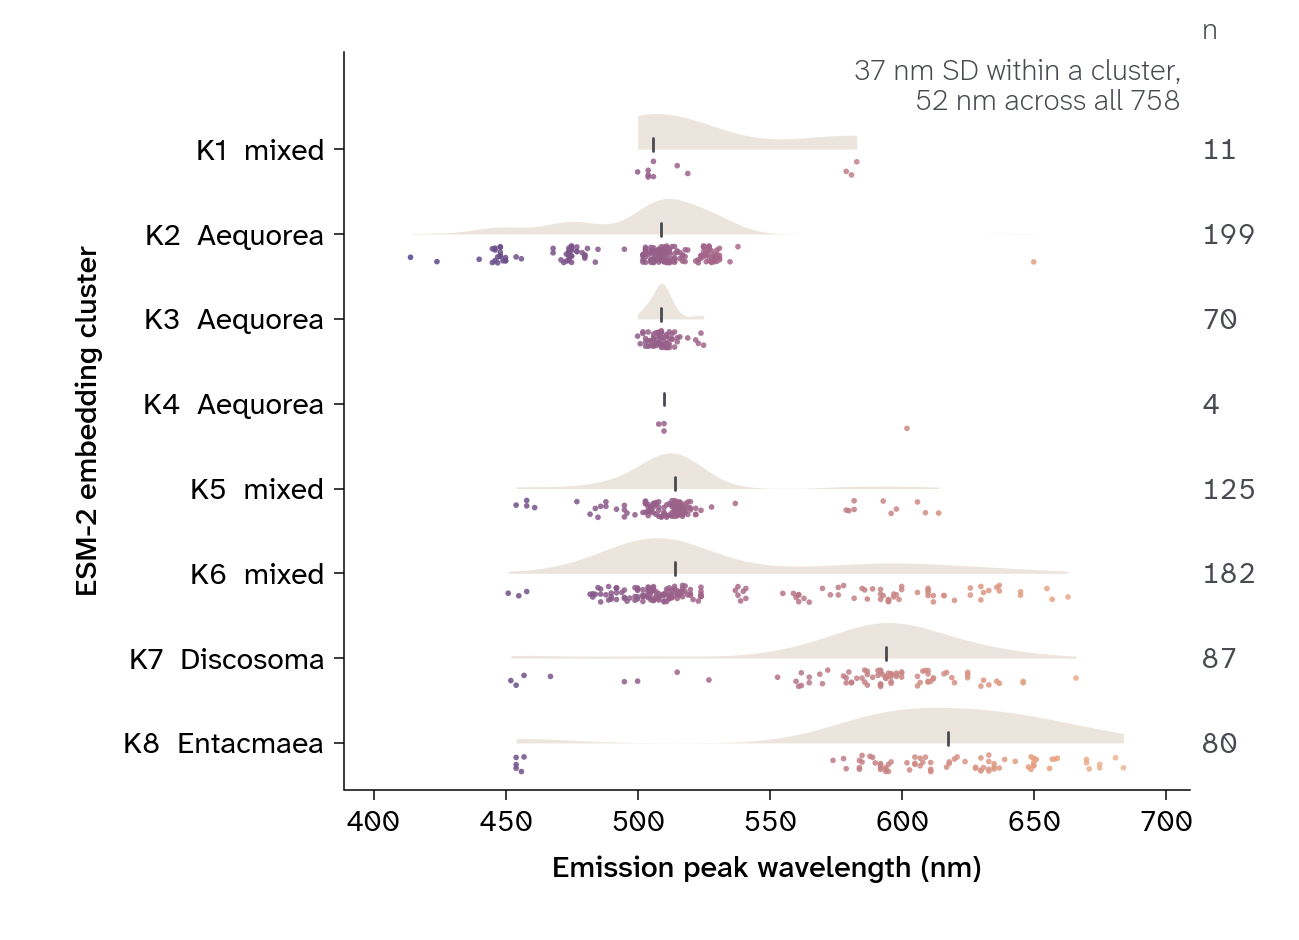

In [13]:
VIOLIN_H, DOT_BAND = 0.42, 0.20   # row heights, in y units (one row per cluster)
EMLIM = (em.min() - 25, em.max() + 25)

fig, ax = plt.subplots(figsize=(FLOAT * PX, 470 * PX))
fig.subplots_adjust(left=0.265, right=0.915, bottom=0.16, top=0.945)

jitter = np.random.default_rng(RNG_SEED)
for i, d in enumerate(clusters):
    v, y = d["v"], len(clusters) - 1 - i
    if d["n"] >= MIN_KDE:
        # Density evaluated only between the cluster's own extremes, so the violin never claims
        # proteins where there are none (seaborn's cut=0 convention).
        grid = np.linspace(v.min(), v.max(), 256)
        dens = gaussian_kde(v)(grid)
        ax.fill_between(grid, y, y + VIOLIN_H * dens / dens.max(),
                        color=NEUTRAL_SOFT, lw=0, alpha=0.55, zorder=1)
    # Every protein also drawn individually, shaded by its own peak on Figure 1's wavelength scale:
    # the off-colour dots inside a cluster are the whole point, and a density alone would hide them.
    ax.scatter(v, y - 0.14 - DOT_BAND * jitter.random(d["n"]), s=8, c=PEAK_CMAP(PEAK_NORM(v)),
               alpha=0.85, lw=0, zorder=3)
    ax.plot([np.median(v)] * 2, [y - 0.02, y + 0.13], color=str(apc.charcoal), lw=1.4, zorder=4)
    ax.annotate(f"{d['n']}", xy=(1.0, y), xycoords=("axes fraction", "data"),
                xytext=(6, -1), textcoords="offset points", ha="left", va="center", **NUMBER_NOTE)

ax.set_yticks(range(len(clusters)))
ax.set_yticklabels([f"K{i}  {d['lineage']}" for i, d in list(enumerate(clusters, 1))[::-1]])
ax.set(xlim=EMLIM, ylim=(-0.55, len(clusters) + 0.15),
       xlabel="Emission peak wavelength (nm)", ylabel="ESM-2 embedding cluster")
apc.mpl.style_plot(ax, monospaced_axes="x")

# Counts head the right-hand column; the spread is stated in place rather than in a legend.
ax.annotate("n", xy=(1.0, 1.0), xycoords="axes fraction", xytext=(6, 4),
            textcoords="offset points", ha="left", va="bottom", **ANNOTATION)
ax.annotate(f"{pooled_within_sd(em, clust):.0f} nm SD within a cluster,\n"
            f"{em_sd:.0f} nm across all {len(em)}",
            xy=(0.99, 0.99), xycoords="axes fraction", ha="right", va="top", **ANNOTATION)

fig.savefig(f"{FIGDIR}/landscape_cluster_emission.svg")
fig.savefig(f"{FIGDIR}/landscape_cluster_emission.png", dpi=200)
plt.show()

**Figure 2. Sequence clusters set a colour expectation, not a colour: knowing which ESM-2 cluster a
protein falls in leaves half the emission variance open.** Emission peak of all 758 curated
proteins, split into 8 k-means clusters of the standardized max-pooled ESM-2 embedding (50 PCs
fitted on all 990 sequenced proteins as in Section 1.1; k-means fitted on the curated rows only;
k chosen in Section 2.1; the identical partition is recovered in the full 1280-d space, ARI 1.00). Rows
are ordered by median emission and named for their dominant source genus where one holds at least
60% of the cluster. Each row shows a kernel density of the cluster's emission peaks (grey, drawn
only for clusters of 10 or more and evaluated only between that cluster's own extremes), every
member as a single dot shaded by its own peak on Figure 1's wavelength scale, and the cluster median
as a tick. Counts are in the right-hand column.

The cluster medians do separate — 506-514 nm for the five green-centred clusters, 594 nm for
*Discosoma* (K7) and 618 nm for *Entacmaea* (K8) — but the distributions overlap almost completely.
Pooled within-cluster SD is 37 nm against 52 nm for the set as a whole, so clustering removes only
about half the emission variance; two proteins from the *same* cluster still differ by a median of
22 nm, and 28% of same-cluster pairs differ by more than 50 nm (against 54 nm and 52% for pairs from
different clusters). The widest rows make the point concretely: K2 (*Aequorea*, n=199) runs from
Sumire at 414 nm to G3GFP at 650 nm, and K8 (*Entacmaea*, n=80) holds mTagBFP2 at 454 nm alongside
mNeptune684 at 684 nm — 230 nm of range inside one sequence cluster. Only K3 is genuinely tight
(500-525 nm, SD 5 nm), and it is not a lineage so much as a single engineered GFP library: 97% of it
is htFuncLib variants of one parent.

None of this is an artefact of k: Section 2.1's sweep leaves the within-cluster spread between 35 and
38 nm for every k from 8 to 20.

As a predictor this is weak. Assigning every protein its cluster's mean emission gives an MAE of
25.2 nm even in-sample, with no held-out penalty at all — against 13.3 nm for the deployed surrogate
and 10.9 nm for the oracle on proteins they have never seen (Figures 6 and 7). Family membership is
a prior on colour; the models have to learn what the residues do inside a family.

### 2.3 The same question with biology's own groups

k-means had to invent its groups. FPbase already ships a grouping that needs no algorithm at all:
the `parent_organism` each protein was engineered from, which recovers the natural lineages — the
*Aequorea* GFP family, the *Discosoma* DsRed / mFruits reds, the *Entacmaea* eqFP line behind mKate
and mScarlet, and the coral families. The rules, the short names and the colours below are lifted
verbatim from
[`../dataset_pipeline/visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb)
(Section 1.2), where each lineage is drawn in the Arcadia colour closest to what its *ancestral
wild-type* FP actually emits — so `avGFP` green for *Aequorea*, `DsRed` orange-red for *Discosoma*,
and so on. Reusing that palette keeps a lineage the same colour in both write-ups.

Per the scope of this section the two catch-all groups (*other*, *synthetic / unassigned*) are
dropped — they are residues of a deliberately conservative rule set, not lineages — and every lineage
with more than 30 curated members gets a row. The panel is laid out exactly like Figure 2, on the same
x-limits, so the two can be read side by side: one row per group, a clipped kernel density above the
baseline, every member as a dot below it, and the group median as a tick. The only change is colour,
which is now the lineage's own ancestral-emission colour rather than each protein's own peak.

In [14]:
import re

# Lineage rules, short names and ancestral-emission colours: verbatim from
# dataset_pipeline/visualize_curation.ipynb Section 1.2. Kept as a copy rather than a shared import
# because these notebooks are each self-contained; if the rules change there, re-sync here.
FAMILY_RULES = [
    ("GFP family — Aequorea",             r"Aequorea"),
    ("DsRed / mFruits — Discosoma",       r"Discosoma"),
    ("eqFP / mKate / mScarlet — Entacmaea", r"Entacmaea"),
    ("Faviina — Kaede / EosFP / Dendra",  r"Lobophyllia|Echinophyllia|Verrillofungia|Montastraea|"
                                          r"Favia|Trachyphyllia|Galaxea|Mycedium|Catalaphyllia|"
                                          r"Scleractinia|Platygyra|Cyphastrea|Dendronephthya"),
    ("Clavularia — mTFP / Kusabira",      r"Clavularia"),
    ("Zoanthus — ZsGreen / ZsYellow",     r"Zoanthus"),
    ("Acropora / Montipora corals",       r"Acropora|Montipora"),
    ("StayGold — Cytaeis",                r"Cytaeis"),
    ("LanYFP / mNeonGreen — Branchiostoma", r"Branchiostoma"),
    ("Bacteriophytochrome IR-FPs",        r"Rhodopseudomonas|Deinococcus|Bradyrhizobium|"
                                          r"Agrobacterium|Xanthomonas|Idiomarina"),
    ("Flavin-based (LOV / miniSOG)",      r"Arabidopsis|Bacillus|Pseudomonas"),
]
# (founding wild-type, its reported emission in nm, the Arcadia colour nearest that emission)
ANCESTOR = {
    "Clavularia — mTFP / Kusabira":        ("cFP484",   484, apc.vital),
    "Flavin-based (LOV / miniSOG)":        ("FMN/LOV",  500, apc.teal),
    "StayGold — Cytaeis":                  ("CU17S",    505, apc.depths),
    "GFP family — Aequorea":               ("avGFP",    509, apc.lime),
    "LanYFP / mNeonGreen — Branchiostoma": ("LanFP1",   510, apc.edamame),
    "Acropora / Montipora corals":         ("atenFP",   515, apc.asparagus),
    "Faviina — Kaede / EosFP / Dendra":    ("Kaede",    518, apc.matcha),
    "Zoanthus — ZsGreen / ZsYellow":       ("zFP538",   538, apc.canary),
    "DsRed / mFruits — Discosoma":         ("DsRed",    583, apc.amber),
    "eqFP / mKate / mScarlet — Entacmaea": ("eqFP611",  611, apc.dragon),
    "Bacteriophytochrome IR-FPs":          ("iRFP713",  713, apc.cinnabar),
}
SHORT = {
    "GFP family — Aequorea":               "GFP family",
    "DsRed / mFruits — Discosoma":         "DsRed / mFruits",
    "eqFP / mKate / mScarlet — Entacmaea": "eqFP / mKate",
    "Faviina — Kaede / EosFP / Dendra":    "Faviina corals",
    "Clavularia — mTFP / Kusabira":        "Clavularia",
    "Zoanthus — ZsGreen / ZsYellow":       "Zoanthus",
    "Acropora / Montipora corals":         "Acropora",
    "StayGold — Cytaeis":                  "StayGold",
    "LanYFP / mNeonGreen — Branchiostoma": "LanYFP",
    "Bacteriophytochrome IR-FPs":          "Bacteriophytochrome",
    "Flavin-based (LOV / miniSOG)":        "Flavin-based LOV",
}
CATCH_ALL = ("other", "synthetic / unassigned")
MIN_FAM = 30             # a lineage joins the overlay only above this many curated members


def family_of(org):
    for label, pat in FAMILY_RULES:
        if re.search(pat, org, re.I):
            return label
    return "synthetic / unassigned" if org in ("", "synthetic construct") else "other"


family = curated.parent_organism.fillna("").map(family_of).to_numpy()
# Key order follows the founder's emission, as in the curation notebook, so the palette reads as a
# spectrum rather than by group size.
fam_order = sorted(ANCESTOR, key=lambda f: ANCESTOR[f][1])
big_fams = [f for f in fam_order if (family == f).sum() > MIN_FAM]

print("lineage              n  founder        median      IQR         span         SD")
for f in fam_order:
    m = family == f
    if not m.sum():
        print(f"{SHORT[f]:19} {m.sum():3d}   (excluded by the pipeline's cofactor rule)")
        continue
    v, (anc, anc_em, _) = em[m], ANCESTOR[f]
    print(f"{SHORT[f]:19} {m.sum():3d}  {anc:8} {anc_em:3d}  {np.median(v):5.1f} nm  "
          f"{np.percentile(v, 25):3.0f}-{np.percentile(v, 75):3.0f}    {v.min():3.0f}-{v.max():3.0f}  "
          f"{v.std(ddof=1):5.1f} nm{'' if f in big_fams else '   (below MIN_FAM)'}")
for f in CATCH_ALL:
    print(f"{f:19} {(family == f).sum():3d}   (dropped: not a lineage)")

in_big = np.isin(family, big_fams)
print(f"\noverlay covers {in_big.sum()} of {len(em)} curated proteins; "
      f"{(~in_big & ~np.isin(family, CATCH_ALL)).sum()} sit in lineages below MIN_FAM={MIN_FAM}")

# Same statistic Figure 2 reports for k-means clusters, on the same proteins, so the two groupings
# can be compared directly rather than across different subsets.
print(f"within-lineage SD {pooled_within_sd(em[in_big], family[in_big]):.1f} nm | "
      f"within-k-means-cluster SD {pooled_within_sd(em[in_big], clust[in_big]):.1f} nm | "
      f"total {em[in_big].std(ddof=1):.1f} nm")
print(f"lineage vs k-means agreement on those proteins: ARI "
      f"{adjusted_rand_score(family[in_big], clust[in_big]):.2f}")
# Figure 2's cluster-mean baseline, restated per lineage on the same proteins.
lin_mean = np.array([em[family == f].mean() for f in family[in_big]])
km_mean = np.array([em[in_big][clust[in_big] == c].mean() for c in clust[in_big]])
print(f"predicting emission as the group mean: lineage {np.abs(em[in_big] - lin_mean).mean():.1f} nm "
      f"| k-means cluster {np.abs(em[in_big] - km_mean).mean():.1f} nm "
      f"| one global mean {np.abs(em[in_big] - em[in_big].mean()).mean():.1f} nm (all in-sample)")
kof = {d["c"]: f"K{i}" for i, d in enumerate(clusters, 1)}
for f in big_fams:
    m = family == f
    top, top_n = Counter(clust[m]).most_common(1)[0]
    fnd = ANCESTOR[f][1]
    print(f"  {SHORT[f]:16} median |em - founder| {np.median(np.abs(em[m] - fnd)):5.1f} nm | "
          f"{100 * np.mean(np.abs(em[m] - fnd) > 50):3.0f}% more than 50 nm from it | "
          f"{100 * top_n / m.sum():3.0f}% falls in one cluster ({kof[top]})")

lineage              n  founder        median      IQR         span         SD
Clavularia           17  cFP484   484  503.0 nm  488-506    461-515   13.2 nm   (below MIN_FAM)
Flavin-based LOV      0   (excluded by the pipeline's cofactor rule)
StayGold             16  CU17S    505  505.5 nm  504-506    504-510    1.9 nm   (below MIN_FAM)
GFP family          275  avGFP    509  509.0 nm  503-514    414-538   22.5 nm
LanYFP               12  LanFP1   510  519.5 nm  515-524    510-592   29.4 nm   (below MIN_FAM)
Acropora             34  atenFP   515  513.0 nm  496-598    483-633   54.2 nm
Faviina corals       98  Kaede    518  514.5 nm  507-517    477-606   22.8 nm
Zoanthus              7  zFP538   538  539.0 nm  522-541    505-576   24.2 nm   (below MIN_FAM)
DsRed / mFruits      81  DsRed    583  591.0 nm  579-611    452-649   42.2 nm
eqFP / mKate         83  eqFP611  611  611.0 nm  593-638    454-684   51.5 nm
Bacteriophytochrome   0   (excluded by the pipeline's cofactor rule)
other    

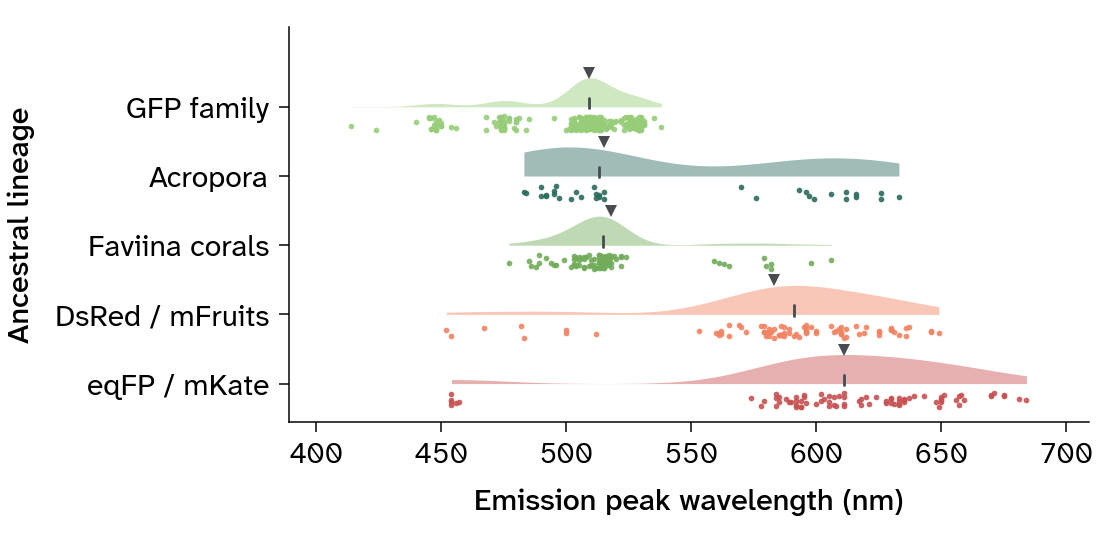

In [15]:
# Same layout, row heights and jitter as Figure 2 (Section 2.2), so a row here and a row there are
# read the same way. Two departures: the violin and its dots take the lineage's own
# ancestral-emission colour from the curation notebook's palette, since the lineage *is* the colour
# claim being made; and each row carries its founding wild-type's emission as a tick above the
# density, which is the wavelength that colour was chosen from.
lineages = [dict(f=f, n=int((family == f).sum()), v=em[family == f], color=str(ANCESTOR[f][2]),
                 founder=ANCESTOR[f][0], founder_em=ANCESTOR[f][1])
            for f in sorted(big_fams, key=lambda f: np.median(em[family == f]))]

FIG_W, FIG_H = FULL_WIDE * 5 / 9, FULL_WIDE * 5 / 18

fig, ax = plt.subplots(figsize=(FIG_W * PX, FIG_H * PX))
fig.subplots_adjust(left=0.26, right=0.98, bottom=0.24, top=0.95)

jitter = np.random.default_rng(RNG_SEED)
for i, d in enumerate(lineages):
    v, y = d["v"], len(lineages) - 1 - i
    grid = np.linspace(v.min(), v.max(), 256)          # clipped, as in Figure 2
    dens = gaussian_kde(v)(grid)
    ax.fill_between(grid, y, y + VIOLIN_H * dens / dens.max(), color=d["color"], lw=0, alpha=0.45,
                    zorder=1)
    ax.scatter(v, y - 0.14 - DOT_BAND * jitter.random(d["n"]), s=8, color=d["color"], alpha=0.9,
               lw=0, zorder=3)
    ax.plot([np.median(v)] * 2, [y - 0.02, y + 0.13], color=str(apc.charcoal), lw=1.4, zorder=4)
    ax.plot([d["founder_em"]], [y + VIOLIN_H + 0.07], marker="v", ms=6, lw=0,
            color=str(apc.charcoal), zorder=4)
#     ax.annotate(f"{d['n']}", xy=(1.0, y), xycoords=("axes fraction", "data"), xytext=(6, -1),
#                 textcoords="offset points", ha="left", va="center", **NUMBER_NOTE)

ax.set_yticks(range(len(lineages)))
ax.set_yticklabels([SHORT[d["f"]] for d in lineages][::-1])
ax.set(xlim=EMLIM, ylim=(-0.55, len(lineages) + 0.15),      # EMLIM: Figure 2's limits, reused
       xlabel="Emission peak wavelength (nm)", ylabel="Ancestral lineage")
apc.mpl.style_plot(ax, monospaced_axes="x")
# ax.annotate("n", xy=(1.0, 1.0), xycoords="axes fraction", xytext=(6, 4),
#             textcoords="offset points", ha="left", va="bottom", **ANNOTATION)
# The marker is named once, beside the top row's, rather than in a legend.
# ax.annotate("founding wild-type", xy=(lineages[0]["founder_em"], len(lineages) - 1 + VIOLIN_H + 0.07),
#             xycoords="data", xytext=(9, 0), textcoords="offset points", ha="left", va="center",
#             **ANNOTATION)

fig.savefig(f"{FIGDIR}/landscape_lineage_emission.svg")
fig.savefig(f"{FIGDIR}/landscape_lineage_emission.png", dpi=200)
plt.show()

**Supporting figure for Figure 2 (biological lineages). Replacing the algorithm's clusters with
FPbase's ancestral lineages gives the same answer: within a family, emission still runs across most of
the visible range.** Emission peak of the 571 curated proteins in the five lineages with more than 30
members, drawn exactly as Figure 2 draws its clusters — one row per group, a kernel density clipped to
that group's own extremes, every member as a dot below it, the median as a tick — and on Figure 2's
x-limits, so the two panels can be read against each other directly. Lineage
assignment is the `parent_organism` regex of
[`../dataset_pipeline/visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb), and
each row takes the Arcadia colour that notebook assigns it: the colour nearest what its founding
wild-type emits. Those founders are marked above each density (avGFP 509 nm, atenFP 515, Kaede 518,
DsRed 583, eqFP611 611); ordering rows by median emission happens to reproduce the founder ordering
exactly. The two catch-all groups are excluded as asked (*other*, 103 proteins; *synthetic /
unassigned*, 32), as are the four genuine but small lineages below 30 members (*Clavularia* 17,
StayGold 16, LanYFP 12, *Zoanthus* 7 — 52 proteins in total); the *Flavin-based* and
*bacteriophytochrome* rules match nothing here, since the pipeline's cofactor rule already removed
those proteins.

Each lineage does sit near its founder, but its full range says how little that settles. Reading down
the rows: the GFP family's median emission is 509 nm over a 414-538 nm range (124 nm wide), *Acropora* /
*Montipora* 513 nm over 483-633 (150 nm), the Faviina corals 514.5 nm over 477-606 (129 nm), DsRed /
mFruits 591 nm over 452-649 (197 nm), and eqFP / mKate 611 nm over 454-684 (230 nm). The medians do
order themselves sensibly — the three green-founded ones span 5.5 nm in total, then a 77 nm step reaches
the two red lineages — but not one of them sits in a range narrower than 124 nm, and the green trio
overlaps almost completely: 77% of the GFP family and 79% of the Faviina corals fall in the same
500-530 nm window. The extremes are where protein engineering shows. *Entacmaea* runs from
Electra1/Bluebonnet2 at 454 nm to mNeptune684 at 684 nm, a 230 nm span within one ancestral family;
*Discosoma* covers 452 nm (mBlueberry1) to 649 nm (mPlum); and 41% of the *Acropora* / *Montipora*
proteins sit more than 50 nm from atenFP's 515 nm, which is what splits that row's density in two. Only
the GFP family is bounded on one side, stopping at 538 nm — no *Aequorea* protein in the set emits
orange or red.

Quantitatively the lineages and the k-means clusters are the same grouping wearing different labels.
On these 571 proteins, within-lineage SD is 33.8 nm and within-cluster SD is 34.5 nm, against 53.6 nm
overall — the hand-written biological rules buy 0.7 nm over what k-means found with no supervision at
all, and the two partitions agree at ARI 0.65 (each lineage's largest cluster holds 71-95% of it,
*Aequorea* splitting only because the htFuncLib library forms its own cluster, K3). As predictors they
are equally weak: assigning every protein its lineage mean gives an in-sample MAE of 22.1 nm, its
cluster mean 23.5 nm, against 44.3 nm for a single global mean — and against 13.3 nm and 10.9 nm for
the surrogate and oracle on proteins they have never seen (Figures 6 and 7). Ancestry sets the
expectation; the residues inside the family decide the colour.

## 3. The nested split

Figure 4 and Figure 5 each rank a 48-architecture sweep, but the two sweeps don't share a split.
Unlike [`../dataset_pipeline/make_dual_split.py`](../dataset_pipeline/make_dual_split.py)'s
coordinated design — where the **surrogate** split is primary and the oracle is carved out to
guarantee every protein trains at least one of the two models — this experiment's own
[`make_dual_split.py`](0_data_split/make_dual_split.py) makes the **oracle** split primary instead: 80/10/10 over
all 758 curated proteins, naive random (no clustering, no fixed pins). The surrogate's data is then
carved *only* from the oracle's training pool (606 proteins), so every surrogate protein is nested
inside oracle-train by construction.

Within those 606 the surrogate uses an **85/15 train/test split** — 515 proteins to fit and select
on, 91 held out — and does all of its model selection by **3-fold cross-validation inside the 515**
(`KFold(3, shuffle=True, random_state=0)`, so each config is fitted on ~343 proteins and scored on
the ~172 left out, three times). The 91-protein test set is touched once, at the very end
(Figure 6). `dual_splits.csv` still records that 515 as `train` 424 + `val` 91, the internal
partition the raw single-split sweep used before the CV pass pooled them; the pool and the 85/15
figure below are the same 515 proteins either way.

The net effect is the opposite of the source design. Rather than guaranteeing every protein trains
something, the oracle's own held-out proteins (152 of 758, its val + test) are excluded from the
surrogate entirely — those 152 are never seen by either model.

In [16]:
from sklearn.model_selection import KFold

N_FOLDS, FOLD_SEED = 3, 0        # the folds cv_all_surrogate.py actually uses

dual = pd.read_csv(DUAL_SPLITS).sort_values("index").reset_index(drop=True)
# dual_splits.csv and peaks_assignments.csv are both built off the same curated index, so a
# straight row check is enough to confirm dual lines up with curated (and so with x, y, ex, em).
assert len(dual) == len(curated), "dual_splits.csv should cover exactly the curated set"
assert (dual.name.to_numpy() == curated.name.to_numpy()).all(), "row order must match curated/x/y"

SURR_ORDER = ["train", "val", "test", "excluded"]
ORACLE_ORDER = ["train", "val", "test"]
ctab = pd.crosstab(dual.surrogate_role, dual.oracle_role).reindex(
    index=SURR_ORDER, columns=ORACLE_ORDER, fill_value=0)
print(ctab)
print()
print("surrogate roles as recorded:", dual.surrogate_role.value_counts().reindex(SURR_ORDER).to_dict())
print("oracle roles:               ", dual.oracle_role.value_counts().reindex(ORACLE_ORDER).to_dict())

# The deployed surrogate protocol: the recorded train+val is one 85% pool that CV subdivides, so
# read the file that way rather than as three fixed roles.
n_pool = int(dual.surrogate_role.isin(["train", "val"]).sum())
n_test = int((dual.surrogate_role == "test").sum())
n_avail = n_pool + n_test
otot = ctab.sum(axis=0)          # per oracle role, across ALL surrogate rows (incl. excluded)
folds = list(KFold(n_splits=N_FOLDS, shuffle=True, random_state=FOLD_SEED).split(np.arange(n_pool)))

print(f"\nsurrogate: {n_avail} available (all nested in oracle-train) -> "
      f"{n_pool} train ({n_pool / n_avail:.0%}) / {n_test} test ({n_test / n_avail:.0%})")
for i, (fit, held) in enumerate(folds, 1):
    print(f"  fold {i}: fit {len(fit)}, held out {len(held)}")
print(f"held out from both models entirely: {(dual.surrogate_role == 'excluded').mean():.0%} of the "
      f"{len(dual)} proteins (the oracle's own val+test, which the surrogate never sees)")

oracle_role     train  val  test
surrogate_role                  
train             424    0     0
val                91    0     0
test               91    0     0
excluded            0   76    76

surrogate roles as recorded: {'train': 424, 'val': 91, 'test': 91, 'excluded': 152}
oracle roles:                {'train': 606, 'val': 76, 'test': 76}

surrogate: 606 available (all nested in oracle-train) -> 515 train (85%) / 91 test (15%)
  fold 1: fit 343, held out 172
  fold 2: fit 343, held out 172
  fold 3: fit 344, held out 171
held out from both models entirely: 20% of the 758 proteins (the oracle's own val+test, which the surrogate never sees)


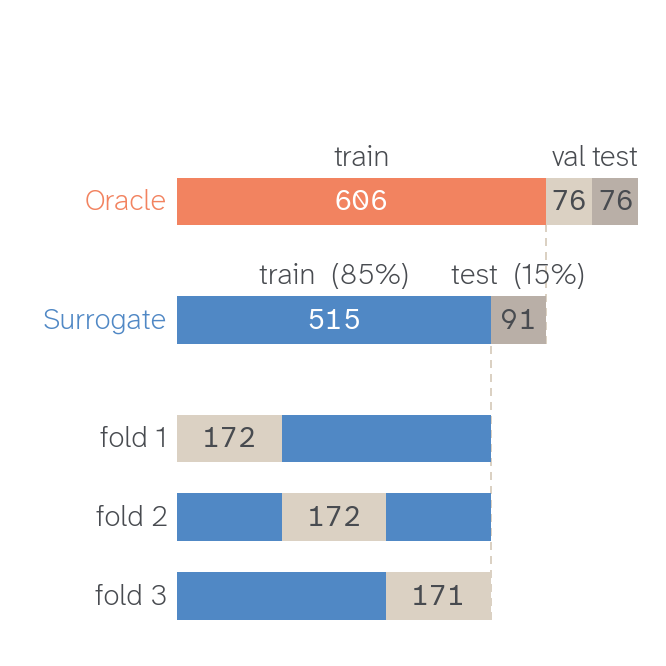

In [17]:
# Nested bars on one shared x-axis of proteins: each row's universe is the coloured block of the row
# above it, so the nesting is read off the alignment rather than drawn as a separate diagram. Colour
# means "fitted on", the two neutrals mean held out -- taupe for a selection hold-out (oracle val,
# each fold's third) and grey for a final test set that is touched once.
BAR_H = 0.60
Y_OR, Y_SU = 5.0, 3.5             # oracle and surrogate rows; the folds sit at 2, 1, 0
n_or = {r: int(otot[r]) for r in ORACLE_ORDER}

FIG_W, FIG_H = FULL_WIDE * 1 / 3, FULL_WIDE * 1 / 3

fig, ax = plt.subplots(figsize=(FIG_W * PX, FIG_H * PX))
fig.subplots_adjust(left=0.115, right=0.985, bottom=0.04, top=0.88)


def block(x0, w, y, color, inside=None, above=None):
    """One segment of a row: count inside the block, role name above it."""
    ax.barh([y], [w], left=x0, height=BAR_H, color=color, ec="none", zorder=2)
    if inside:
        ax.text(x0 + w / 2, y, inside, ha="center", va="center", zorder=3,
                **{**NUMBER_NOTE,
                   "color": "white" if color in (HIGHLIGHT, CONTRAST) else str(apc.charcoal)})
    if above:
        ax.text(x0 + w / 2, y + BAR_H / 2 + 0.10, above, ha="center", va="bottom", **ANNOTATION)


# Guides for the two nestings: the surrogate's universe is oracle-train, the folds' is surrogate-train.
ax.plot([n_or["train"]] * 2, [Y_SU - BAR_H / 2, Y_OR - BAR_H / 2], color=NEUTRAL_SOFT, lw=1.0,
        ls=(0, (4, 3)), zorder=0)
ax.plot([n_pool] * 2, [-BAR_H / 2, Y_SU - BAR_H / 2], color=NEUTRAL_SOFT, lw=1.0, ls=(0, (4, 3)),
        zorder=0)

block(0, n_or["train"], Y_OR, CONTRAST, inside=f"{n_or['train']}", above="train")
block(n_or["train"], n_or["val"], Y_OR, NEUTRAL_SOFT, inside=f"{n_or['val']}", above="val")
block(n_or["train"] + n_or["val"], n_or["test"], Y_OR, NEUTRAL, inside=f"{n_or['test']}", above="test")
ax.text(-16, Y_OR, "Oracle", ha="right", va="center", **{**ANNOTATION, "color": CONTRAST})

block(0, n_pool, Y_SU, HIGHLIGHT, inside=f"{n_pool}", above=f"train  ({n_pool / n_avail:.0%})")
block(n_pool, n_test, Y_SU, NEUTRAL, inside=f"{n_test}", above=f"test  ({n_test / n_avail:.0%})")
ax.text(-16, Y_SU, "Surrogate", ha="right", va="center", **{**ANNOTATION, "color": HIGHLIGHT})

# Fold blocks are drawn contiguous for legibility; the real KFold(shuffle=True) folds are random
# thirds of the pool, which as a barcode reads as noise rather than as "one third held out".
edges = np.linspace(0, n_pool, N_FOLDS + 1).round().astype(int)
for i, (fit, held) in enumerate(folds):
    y, lo, hi = N_FOLDS - 1 - i, edges[i], edges[i + 1]
    block(0, n_pool, y, HIGHLIGHT)
    block(lo, hi - lo, y, NEUTRAL_SOFT, inside=f"{len(held)}")
    ax.text(-16, y, f"fold {i + 1}", ha="right", va="center", **ANNOTATION)

ax.set_xlim(-165, len(dual) + 30)
ax.set_ylim(-0.55, Y_OR + 1.55)
ax.axis("off")

fig.savefig(f"{FIGDIR}/dual_split_overview.svg")
fig.savefig(f"{FIGDIR}/dual_split_overview.png", dpi=200)
plt.show()

**Figure 3. The surrogate's data is nested inside the oracle's training pool, split 85/15, and
cross-validated three ways inside the 85.** Every row is drawn on the same axis of curated proteins,
so each row's universe is the coloured block of the row above it. **Oracle:** a naive-random 80/10/10
over all 758 — train 606, val 76, test 76. **Surrogate:** carved only from those 606, and split 85/15
into a 515-protein pool and a 91-protein test set. **Folds:** `KFold(3, shuffle=True,
random_state=0)` within the 515, so each of Figure 4's 48 configurations is fitted three times on
343-344 proteins and scored on the 171-172 left out. Fold blocks are drawn as contiguous thirds for
legibility — the actual folds are random thirds of the pool. Colour means fitted on; the two neutrals
mean held out, taupe for a selection hold-out (the oracle's val, each fold's third) and grey for a
test set touched once at the end (Figures 6 and 7).

The nesting has a consequence worth stating plainly: the surrogate row stops where the oracle's train
block stops, so the 152 proteins in the oracle's own val + test (20% of the curated set) are seen by
**neither** model. That is the opposite of
[`../dataset_pipeline/make_dual_split.py`](../dataset_pipeline/make_dual_split.py)'s coordinated
design, where the surrogate split is primary and the oracle is carved out so that every protein
trains at least one of the two. Both splits here are random and unclustered, with no proteins pinned
to fixed roles.

One bookkeeping note: `dual_splits.csv` records the 515 as two roles, `train` 424 and `val` 91,
because the first pass over the 48 architectures was a single-split sweep that used exactly that
partition. Cross-validation pools them, and every number quoted from Figure 4 onward is on the pooled
515 — so the file's three surrogate roles and this figure's two describe the same proteins.

## 4. Architecture sweep for the surrogate peak model

The surrogate that guides generation is chosen from the same 48-architecture grid as the source
pipeline: three backbones (`mlp` pool-only, `cnn`, `transformer`) crossed with pooling readouts
`mean`, `max`, `concat`, `concatstd`, `attn`, plus the covariance-probe pool `cov`
($z_i = W^\top x_i$, then $C_z = \tfrac{1}{L}\sum_i z_i z_i^\top$, flattened over its upper
triangle) at CNN depth 1-3, and, for `cnn`/`transformer`, depth 1-4. Every configuration is trained
once (seed 0) on the ESM-2 embedding of an internal 424/91 train/val partition of Figure 3's
515-protein pool, with the same 91-protein test set held out, and scored by validation MAE, averaged over excitation and emission — see
[`sweep_peak_oracle.py`](1_surrogate_oracle_training/sweep_peak_oracle.py).

That single-split ranking is noisy over only 91 validation proteins, so before committing to a
config it is re-run through 3-fold cross-validation on the pooled train+val (515 proteins,
[`cv_all_surrogate.py`](1_surrogate_oracle_training/cv_all_surrogate.py)), refitting each of the 48 configs three times on
random folds with a fixed 91-row test held out throughout as a common yardstick. **This figure is
that cross-validated ranking, not the raw single-split sweep** — the two disagree on the winner
(see the caption below).

An embedding-nearest-neighbour baseline is pinned alongside the ranking: predict a held-out
protein's peak as the mean peak of its *k* nearest training proteins in mean-pooled ESM-2 space
(cosine distance, *k* = 1, 3, 5, 10, 20). It is run through the **same three folds** as the configs
— same pool, same `KFold(3, shuffle=True, random_state=0)`, so the same proteins are held out — and
carries the same fold-to-fold error bars. That matters because a null fitted on the full 424-row
train split is not comparable to configs fitted on 343: retrieval baselines gain directly with the
number of proteins available to retrieve from, and the earlier single-split version of this figure
(20.0 nm at *k* = 1) flattered the null by ~5 nm for that reason alone.

In [18]:
import glob
import re

import torch

BACKBONE_LABEL = {"cnn": "CNN", "transformer": "TF", "mlp": "None"}
SURR_DIR = "trained_models/surrogate_sweep"
CV_CSV = "trained_models/surrogate_cv3.csv"


def load_surrogate_sweep(out_dir):
    """One row per checkpoint: architecture/pooling/depth and its (single-split) validation MAE (nm)."""
    recs = []
    for p in sorted(glob.glob(f"{out_dir}/*.pt")):
        ck = torch.load(p, map_location="cpu", weights_only=False)
        recs.append(dict(
            arch=ck["arch"], pool=ck["pool"], depth=ck["depth"],
            label=f"{BACKBONE_LABEL[ck['arch']]} ({ck['depth']}) - {ck['pool']}",
            val_mae=ck["val_mae"], test_mae=ck["test_mae"],
        ))
    return pd.DataFrame(recs).sort_values("val_mae").reset_index(drop=True)


def load_surrogate_cv(csv_path):
    """One row per config: architecture/pooling/depth and its 3-fold CV fold-val / fixed-test MAE
    (nm, mean +/- SD across folds) -- this is the ranking that actually picked the surrogate.
    """
    cv = pd.read_csv(csv_path)
    recs = []
    for label, g in cv.groupby("label"):
        arch, pool, depth = re.match(r"([a-z]+)-([a-z]+)-d(\d+)", label).groups()
        recs.append(dict(
            arch=arch, pool=pool, depth=int(depth),
            label=f"{BACKBONE_LABEL[arch]} ({depth}) - {pool}",
            val_mae=g.fold_va_mae.mean(), val_std=g.fold_va_mae.std(),
            test_mae=g.fixed_test_mae.mean(), test_std=g.fixed_test_mae.std(),
        ))
    return pd.DataFrame(recs).sort_values("val_mae").reset_index(drop=True)


sweep = load_surrogate_cv(CV_CSV)
best, worst = sweep.iloc[0], sweep.iloc[-1]
print(f"{len(sweep)} configs (3-fold CV) | best {best['label']} at {best.val_mae:.1f} +/- "
      f"{best.val_std:.1f} nm fold-val ({best.test_mae:.1f} +/- {best.test_std:.1f} nm fixed-test) | "
      f"worst {worst['label']} at {worst.val_mae:.1f} nm")

raw_sweep = load_surrogate_sweep(SURR_DIR)          # single-split sweep, for contrast only
raw_best = raw_sweep.iloc[0]
cv_rank_of_raw_best = int(sweep.index[sweep.label == raw_best["label"]][0]) + 1
print(f"raw single-split sweep top pick: {raw_best['label']} at {raw_best.val_mae:.1f} nm val "
      f"-- ranks {cv_rank_of_raw_best} of {len(sweep)} once cross-validated")

48 configs (3-fold CV) | best CNN (1) - max at 15.3 +/- 1.4 nm fold-val (18.8 +/- 2.2 nm fixed-test) | worst CNN (3) - cov at 27.5 nm
raw single-split sweep top pick: CNN (2) - concat at 11.4 nm val -- ranks 3 of 48 once cross-validated


In [19]:
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors

K_SWEEP = [1, 3, 5, 10, 20]
N_FOLDS, FOLD_SEED = 3, 0          # identical to cv_all_surrogate.py / cv_surrogate_top5.py


def surrogate_nn_baseline(ks=K_SWEEP):
    """Embedding-NN null: predict a held-out peak as the mean peak of its k nearest training
    proteins in mean-pooled ESM-2 space -- the same per-residue cache the sweep trains on, pooled
    the simple way rather than learned.

    Run through the SAME 3-fold partition as the configs it is plotted against: pool =
    concat(train, val) in that exact order, KFold(3, shuffle=True, random_state=0), neighbours
    fitted on each fold's ~343 training rows and scored on its ~172 held-out rows. Since KFold
    shuffles by position and the pool array is built the same way here as in cv_all_surrogate.py,
    the folds contain the same proteins -- so the null bars and the config bars are answering the
    question on identical data, not merely on comparable protocols.

    A k-NN has no epochs, so unlike the configs it gets no early-stopping pick on its own held-out
    fold; that asymmetry favours the configs and is worth remembering when reading the margin.
    Returns {label: (mean, SD)} over folds, plus the single-split value for continuity with the
    earlier version of this figure.
    """
    peaks = np.load(f"{CURATED}/peaks.npy").astype(np.float32)
    H = np.load(f"{CURATED}/esm_residue_fp16.npy")
    Ls = np.load(f"{CURATED}/esm_residue_len.npy").astype(int)
    role = (pd.read_csv(DUAL_SPLITS)
            .sort_values("index").set_index("index")["surrogate_role"].to_numpy())
    tr, va = np.where(role == "train")[0], np.where(role == "val")[0]
    pool = np.concatenate([tr, va])

    X = np.stack([H[i, :Ls[i]].astype(np.float32).mean(0) for i in range(len(H))])

    def nn_mae(fit_idx, eval_idx, k):
        nn = NearestNeighbors(n_neighbors=k, metric="cosine").fit(X[fit_idx])
        pred = peaks[fit_idx][nn.kneighbors(X[eval_idx], return_distance=False)].mean(axis=1)
        return float(np.abs(pred - peaks[eval_idx]).mean())

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=FOLD_SEED)
    folds = list(kf.split(pool))
    cv, single = {}, {}
    for k in ks:
        per_fold = [nn_mae(pool[tri], pool[vai], k) for tri, vai in folds]
        cv[f"NN k={k}"] = (float(np.mean(per_fold)), float(np.std(per_fold, ddof=1)))
        single[f"NN k={k}"] = nn_mae(tr, va, k)          # fixed 70/15/15, the old comparison
    return cv, single


nulls, nulls_single = surrogate_nn_baseline()
best_null = min(m for m, _ in nulls.values())
worst_null = max(m for m, _ in nulls.values())
n_below_best_null = int((sweep.val_mae > best_null).sum())
n_below_worst_null = int((sweep.val_mae > worst_null).sum())
for k, (m, s) in nulls.items():
    print(f"{k:8} {m:5.1f} +/- {s:4.1f} nm  (fixed 70/15/15: {nulls_single[k]:5.1f} nm)")
print(f"best null {best_null:.1f} nm vs winner {sweep.val_mae.min():.1f} nm "
      f"-- margin {best_null - sweep.val_mae.min():.1f} nm")
print(f"{n_below_best_null} of {len(sweep)} configs are worse than the best null; "
      f"{n_below_worst_null} are worse than every null")


NN k=1    24.7 +/-  3.2 nm  (fixed 70/15/15:  20.0 nm)
NN k=3    25.7 +/-  1.2 nm  (fixed 70/15/15:  20.5 nm)
NN k=5    25.8 +/-  2.4 nm  (fixed 70/15/15:  21.7 nm)
NN k=10   27.5 +/-  2.4 nm  (fixed 70/15/15:  21.9 nm)
NN k=20   29.2 +/-  2.0 nm  (fixed 70/15/15:  23.5 nm)
best null 24.7 nm vs winner 15.3 nm -- margin 9.3 nm
7 of 48 configs are worse than the best null; 0 are worse than every null


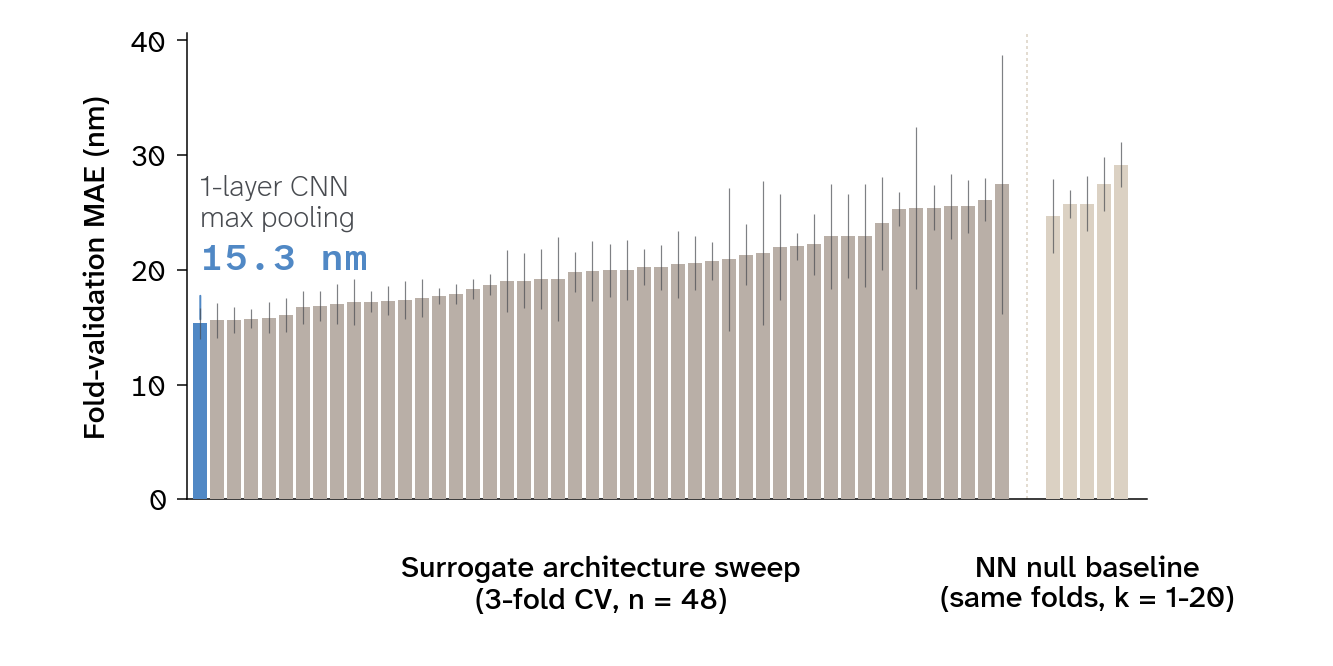

In [20]:
# Best config in HIGHLIGHT; everything else -- other configs and null baselines alike -- recedes
# into neutral tones, per the guide's "one series emphasized, the rest recede" pattern. Error bars
# (fold-to-fold SD) are new here versus the single-split version of this figure, since that spread
# is the whole reason a CV pass was run in the first place.
ranked = sweep.sort_values("val_mae", ascending=True).reset_index(drop=True)
null_items = [(lab, m, s) for lab, (m, s) in nulls.items()]   # (label, mean, fold SD)
best = ranked.iloc[0]
GAP = 2.0
x_cfg = np.arange(len(ranked))
x_null = np.arange(len(null_items)) + len(ranked) + GAP
bar_color = [HIGHLIGHT if i == 0 else NEUTRAL for i in range(len(ranked))]

fig, ax = plt.subplots(figsize=(2 / 3 * FULL_WIDE * PX, 1 / 3 * FULL_WIDE * PX))
fig.subplots_adjust(left=0.14, right=0.86, top=0.95, bottom=0.25)

ax.bar(x_cfg, ranked["val_mae"], color=bar_color, width=0.82, edgecolor="none", zorder=3)
ax.errorbar(x_cfg, ranked["val_mae"], yerr=ranked["val_std"], fmt="none",
            ecolor=str(apc.charcoal), elinewidth=0.6, capsize=1.5, zorder=4, alpha=0.7)
ax.bar(x_null, [m for _, m, _ in null_items], color=NEUTRAL_SOFT, width=0.82,
       edgecolor="none", zorder=3)
# Same fold-to-fold error bars as the configs -- the null is now run through the same 3 folds,
# so it earns the same uncertainty mark rather than reading as a single exact number.
ax.errorbar(x_null, [m for _, m, _ in null_items], yerr=[s for _, _, s in null_items], fmt="none",
            ecolor=str(apc.charcoal), elinewidth=0.6, capsize=1.5, zorder=4, alpha=0.7)
ax.axvline(len(ranked) - 0.5 + GAP / 2, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.75, zorder=2)

# Individual configs are no longer the point -- only the winner is labelled, with a leader line
# and its exact fold-validation MAE set in the guide's mono numerals, SemiBold for emphasis.
best_text = f"{best.depth}-layer {BACKBONE_LABEL[best.arch]}\n{best['pool']} pooling"
ax.annotate(best_text, xy=(0, best.val_mae), xycoords="data",
            xytext=(0, 46), textcoords="offset points", ha="left", va="bottom", **ANNOTATION)
ax.annotate(f"{best.val_mae:.1f} nm", xy=(0, best.val_mae), xycoords="data",
            xytext=(0, 24), textcoords="offset points", ha="left", va="bottom",
            **{**NUMBER_NOTE, "fontsize": 19, "fontweight": "semibold", "color": HIGHLIGHT})
ax.annotate("", xy=(0, best.val_mae), xytext=(0, best.val_mae + ranked["val_mae"].max() * 0.10),
            arrowprops=dict(arrowstyle="-", color=HIGHLIGHT, lw=1))

ax.set_xticks([])
ax.set_xlim(-0.8, x_null.max() + 1.5)          # headroom so the null label clears the last bar
ax.set_ylim(0, max((ranked["val_mae"] + ranked["val_std"]).max(),
                   max(m + s for _, m, s in null_items)) * 1.05)
ax.set_ylabel("Fold-validation MAE (nm)")

# No legend -- each group is labelled in place, centred under its own bars, rather than decoded
# through a key. Blended transform: x in data coordinates, y in axes fraction (below the spines).
label_style = dict(fontsize=plt.rcParams["axes.labelsize"], color=plt.rcParams["axes.labelcolor"],
                   fontweight=plt.rcParams["axes.labelweight"])
ax.text(x_cfg.mean(), -0.12, "Surrogate architecture sweep\n(3-fold CV, n = 48)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)
ax.text(x_null.mean(), -0.12, "NN null baseline\n(same folds, k = 1-20)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)

apc.mpl.style_plot(ax, monospaced_axes="y")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="x", length=0)

fig.savefig(f"{FIGDIR}/peak_surrogate_sweep_cv_mae.svg")
fig.savefig(f"{FIGDIR}/peak_surrogate_sweep_cv_mae.png", dpi=200)
plt.show()

**Figure 4. Three-fold cross-validation, not the single 70/15/15 split, is what actually confirms
CNN (1) - max as the surrogate -- and on matched folds it clears the strongest null baseline by
9.4 nm.** Mean fold-validation MAE (nm, ± 1 SD across 3 folds, averaged over excitation and
emission) for all 48 backbone x pooling x depth configurations, each refit three times
([`cv_all_surrogate.py`](1_surrogate_oracle_training/cv_all_surrogate.py)) on random 3-fold splits of the surrogate train+val
pool (515 proteins), ranked against an embedding-nearest-neighbour null (cosine distance over
mean-pooled ESM-2, *k* = 1, 3, 5, 10, 20) run through **those same three folds**, with the same
fold-to-fold error bars. The winner is called out in Aegean.

On the raw single-split sweep ([`sweep_peak_oracle.py`](1_surrogate_oracle_training/sweep_peak_oracle.py), the same protocol
run once with no folds) CNN (1) - max actually ranks 4th, marginally behind CNN (2) - concat (11.4
vs 11.7 nm val) — a gap well inside the noise of one 91-protein validation set. Cross-validation
settles it: CNN (1) - max has both the lowest mean fold-validation MAE (15.3 ± 1.4 nm) and the
lowest fixed-test MAE (18.8 ± 2.2 nm, on the 91-row test set every fold shares) of all 48
configurations. Seven of the 48 fail to clear the strongest null (*k* = 1, 24.7 ± 3.2 nm) and none
falls behind every null tested.

Matching the folds costs the null about 5 nm and is the honest way to run it: on the fixed 70/15/15
split the same *k* = 1 null reads 20.0 nm, but there it retrieves from all 424 training proteins
while every cross-validated config was fitted on a fold's 343. Retrieval baselines gain directly
with the number of proteins available to match against, so the earlier version of this figure was
comparing across a data-size difference rather than across methods. Two asymmetries remain in the
configs' favour and are worth reading the 9.4 nm margin against: each config gets to pick its best
epoch on the very fold it is scored on, which a *k*-NN has no analogue for, and *k* = 1 was chosen
after seeing all five values (it wins on every fold, so this changes nothing).

Depth and pooling interact the way the raw sweep already suggested: CNNs hold their edge shallow
(mean fold-va MAE 17.0 and 17.7 nm at depth 1-2) and degrade from depth 3 (20.1, 20.7 nm);
transformers are flatter through depth 2 (18.7, 18.6 nm) before falling off from depth 3 (21.4 nm)
and further at depth 4 (24.6 nm). The covariance-probe pool is competitive at CNN depth 1-2 but its
depth-3 variant isn't just worse, it's unstable: CNN (3) - cov is both the single worst
configuration in the grid (27.5 nm) and by far the least reproducible across folds (± 11.3 nm) —
the same depth-3 breakdown Figure 5 flags on the oracle sweep, more severe there.

## 5. Architecture sweep for the oracle peak model

The oracle evaluates designs independently of the surrogate: the same backbone x pooling x depth
sweep and protocol, but on a ProstT5 encoder embedding (structure-aware, 1024-d) and this
experiment's own oracle-role split (606/76/76 train/val/test), so it differs from the surrogate in
both the pretrained language model and the split it is scored against, not just the trained
readout. Sweep code lives in the same [`sweep_peak_oracle.py`](1_surrogate_oracle_training/sweep_peak_oracle.py) as Figure 4;
this is that sweep's ranking, in the same style, so the two can be compared directly. Unlike the
surrogate, the oracle here is scored on the raw single-split sweep — no CV pass was run for it in
this experiment.

As in Figure 4, an embedding-nearest-neighbour null is pinned separately: predict a validation
protein's peak as the mean peak of its *k* nearest training proteins in mean-pooled ProstT5 space
(cosine distance, *k* = 1, 3, 5, 10, 20).

In [21]:
ORACLE_DIR = "trained_models/oracle_sweep"

# load_surrogate_sweep is generic despite the name -- any checkpoint dir with the same fields.
oracle_sweep = load_surrogate_sweep(ORACLE_DIR)
oracle_best, oracle_worst = oracle_sweep.iloc[0], oracle_sweep.iloc[-1]
print(f"{len(oracle_sweep)} configs | best {oracle_best['label']} at {oracle_best.val_mae:.1f} nm val "
      f"({oracle_best.test_mae:.1f} nm test) | worst {oracle_worst['label']} at {oracle_worst.val_mae:.1f} nm")

48 configs | best CNN (1) - max at 8.7 nm val (12.3 nm test) | worst CNN (3) - cov at 37.4 nm


In [22]:
def oracle_nn_baseline(ks=K_SWEEP):
    """Same embedding-NN null as Figure 4, on the oracle's ProstT5 cache and split -- but on the
    single 80/10/10 split rather than folds, because the ORACLE was itself selected that way (no CV
    was run for it). Each side of this figure therefore uses one train fit and one validation
    score, so the null and the configs stay protocol-matched here too.
    """
    peaks = np.load(f"{CURATED}/peaks.npy").astype(np.float32)
    H = np.load(f"{CURATED}/prostt5_residue_fp16.npy")
    Ls = np.load(f"{CURATED}/prostt5_residue_len.npy").astype(int)
    role = (pd.read_csv(DUAL_SPLITS)
            .sort_values("index").set_index("index")["oracle_role"].to_numpy())
    tr, va = np.where(role == "train")[0], np.where(role == "val")[0]

    X = np.stack([H[i, :Ls[i]].astype(np.float32).mean(0) for i in range(len(H))])
    out = {}
    for k in ks:
        nn = NearestNeighbors(n_neighbors=k, metric="cosine").fit(X[tr])
        neighbours = nn.kneighbors(X[va], return_distance=False)
        pred = peaks[tr][neighbours].mean(axis=1)
        out[f"NN k={k}"] = float(np.abs(pred - peaks[va]).mean())
    return out


oracle_nulls = oracle_nn_baseline()
n_below_best_null = int((oracle_sweep.val_mae > min(oracle_nulls.values())).sum())
n_below_worst_null = int((oracle_sweep.val_mae > max(oracle_nulls.values())).sum())
for k, v in oracle_nulls.items():
    print(f"{k:8} {v:5.1f} nm")
print(f"{n_below_best_null} of {len(oracle_sweep)} configs are worse than the best null; "
      f"{n_below_worst_null} are worse than every null")

NN k=1    16.7 nm
NN k=3    18.9 nm
NN k=5    18.0 nm
NN k=10   21.8 nm
NN k=20   23.3 nm
6 of 48 configs are worse than the best null; 1 are worse than every null


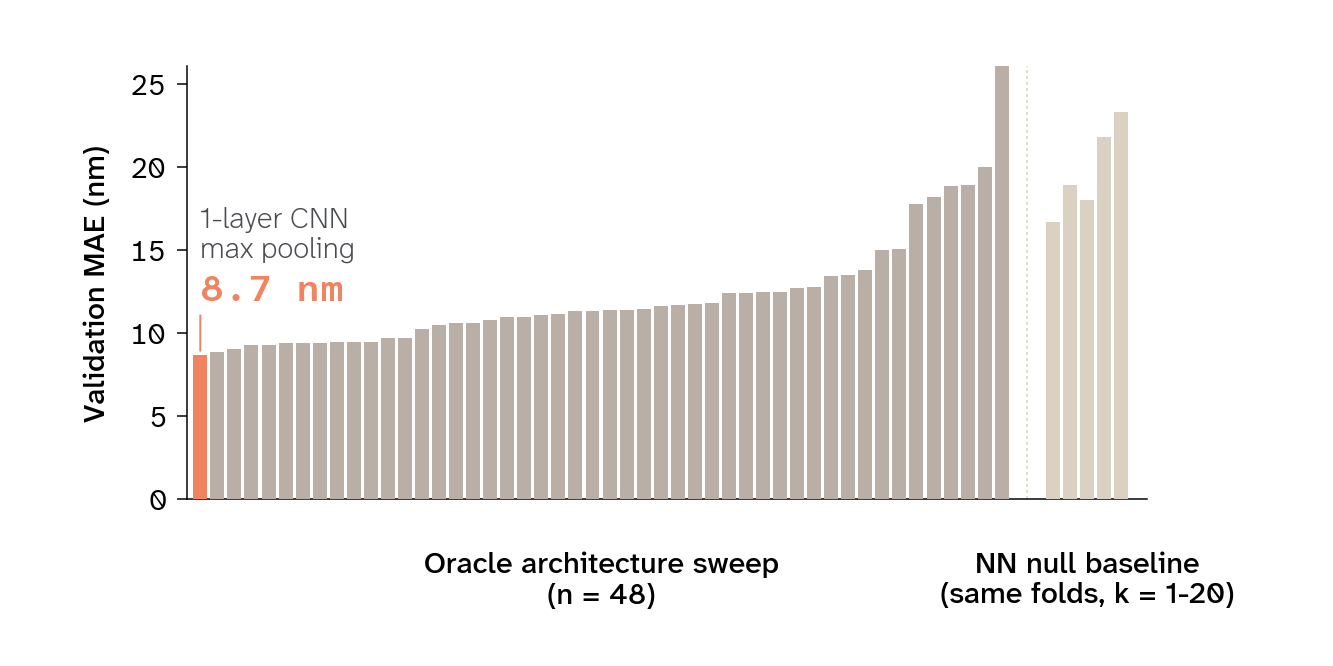

In [23]:
# Same design as Figure 4, but the winner is called out in CONTRAST (orange) rather than
# HIGHLIGHT, so the two sweep figures read as a pair with a distinct colour per model. CNN (3) -
# cov is such a severe outlier (37 nm, versus a 20 nm runner-up) that it would compress the other
# 47 bars into a sliver if the axis stretched to fit it, so the axis is capped near the runner-up
# and that one bar is simply clipped -- still present in the chart, just cut off at the top, with
# no callout text on it.
oracle_ranked = oracle_sweep.sort_values("val_mae", ascending=True).reset_index(drop=True)
oracle_null_items = list(oracle_nulls.items())
oracle_best_row = oracle_ranked.iloc[0]
GAP = 2.0
x_cfg = np.arange(len(oracle_ranked))
x_null = np.arange(len(oracle_null_items)) + len(oracle_ranked) + GAP
bar_color = [CONTRAST if i == 0 else NEUTRAL for i in range(len(oracle_ranked))]

ylim_max = max(oracle_ranked["val_mae"].iloc[:-1].max(),
               max(v for _, v in oracle_null_items)) * 1.12

fig, ax = plt.subplots(figsize=(2 / 3 * FULL_WIDE * PX, 1 / 3 * FULL_WIDE * PX))
fig.subplots_adjust(left=0.14, right=0.86, top=0.9, bottom=0.25)

ax.bar(x_cfg, oracle_ranked["val_mae"], color=bar_color, width=0.82, edgecolor="none", zorder=3)
ax.bar(x_null, [v for _, v in oracle_null_items], color=NEUTRAL_SOFT, width=0.82,
       edgecolor="none", zorder=3)
ax.axvline(len(oracle_ranked) - 0.5 + GAP / 2, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.75, zorder=2)

# Only the winner is labelled, with a leader line and its exact validation MAE set in the guide's
# mono numerals, SemiBold for emphasis.
best_text = f"{oracle_best_row.depth}-layer {BACKBONE_LABEL[oracle_best_row.arch]}\n{oracle_best_row['pool']} pooling"
ax.annotate(best_text, xy=(0, oracle_best_row.val_mae), xycoords="data",
            xytext=(0, 46), textcoords="offset points", ha="left", va="bottom", **ANNOTATION)
ax.annotate(f"{oracle_best_row.val_mae:.1f} nm", xy=(0, oracle_best_row.val_mae), xycoords="data",
            xytext=(0, 24), textcoords="offset points", ha="left", va="bottom",
            **{**NUMBER_NOTE, "fontsize": 19, "fontweight": "semibold", "color": CONTRAST})
ax.annotate("", xy=(0, oracle_best_row.val_mae),
            xytext=(0, oracle_best_row.val_mae + ylim_max * 0.10),
            arrowprops=dict(arrowstyle="-", color=CONTRAST, lw=1))

ax.set_xticks([])
ax.set_xlim(-0.8, x_null.max() + 1.5)
ax.set_ylim(0, ylim_max)
ax.set_ylabel("Validation MAE (nm)")

label_style = dict(fontsize=plt.rcParams["axes.labelsize"], color=plt.rcParams["axes.labelcolor"],
                   fontweight=plt.rcParams["axes.labelweight"])
ax.text(x_cfg.mean(), -0.12, "Oracle architecture sweep\n(n = 48)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)
ax.text(x_null.mean(), -0.12, "NN null baseline\n(same folds, k = 1-20)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)

apc.mpl.style_plot(ax, monospaced_axes="y")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="x", length=0)

fig.savefig(f"{FIGDIR}/peak_oracle_sweep_val_mae.svg")
fig.savefig(f"{FIGDIR}/peak_oracle_sweep_val_mae.png", dpi=200)
plt.show()

**Figure 5. The independently-scored oracle confirms the same winning architecture, CNN (1) -
max, and cuts its null baseline's error by a larger fraction than the surrogate does.** Validation MAE (nm,
averaged over excitation and emission) for the same 48-configuration sweep
([`sweep_peak_oracle.py`](1_surrogate_oracle_training/sweep_peak_oracle.py)), trained once (seed 0) on the ProstT5 embedding
and this experiment's own oracle-role split (606/76/76 train/val/test,
[`make_dual_split.py`](0_data_split/make_dual_split.py)), ranked against an embedding-nearest-neighbour null on
the same ProstT5 space (*k* = 1, 3, 5, 10, 20). CNN (1) - max is called out in Amber, pairing with
Figure 4's blue.

**CNN (3) - cov** is clipped off the top of the axis rather than plotted at scale: at 37.4 nm it is
almost double the next-worst configuration (**None (0) - mean**, the pool-only baseline, 20.0 nm)
and would compress the other 47 bars into a sliver if the axis stretched to fit it — the same
depth-3 covariance-probe breakdown Figure 4 flags as unstable on the surrogate, more severe here.
Set that one outlier aside and only 5 of 48 configurations fail to beat the strongest null (*k*=1,
16.7 nm), and nothing but the clipped outlier falls behind every null tested — a cleaner sweep than
the surrogate's. The right way to compare that across the two panels is relative, not absolute: the
oracle's winner cuts its null's error by 48% (8.7 vs 16.7 nm) against the surrogate's 38% (15.3 vs
24.7 nm). The absolute gaps — 8.0 nm here, 9.4 nm in Figure 4 — are not comparable, because the
oracle sweep and its null both fit on 606 proteins under one split while Figure 4's configs and
null both fit on a fold's 343.

Depth behaves differently on ProstT5 than on ESM-2: CNN performance is close through depth 1-2
(11.1, 10.4 nm) and, once the depth-3 outlier is set aside, stays in that same range through depth
4 (10.9, 11.6 nm) rather than degrading monotonically; transformers hold flat through depth 3
(11.2, 10.8, 10.9 nm) and only fall off at depth 4 (13.6 nm) — one depth later than the surrogate's
transformer cliff. Mean pooling still never reaches the top half of the ranking (best rank 19,
**TF (3) - mean** at 11.0 nm).

## 6. Test-set predictions: the deployed surrogate

Figure 4 ranked all 48 surrogate configs by 3-fold CV MAE — but the model actually used to guide
design isn't any one of those fold-models (each only trained on two-thirds of the pool). Once CNN
(1) - max was confirmed as the architecture, it was refit once more on the *full* train+val pool
(515 proteins, [`train_final_surrogate.py`](1_surrogate_oracle_training/train_final_surrogate.py)), with the epoch budget fixed
at 71 — the mean of the epoch each CV fold early-stopped at — since there is no held-out val left
to early-stop on once train and val are both used for fitting. This is that final, once-refit
model, run here on the 91-row test split it has never seen in any form. The oracle's equivalent is
Figure 7.

In [24]:
# experiment root + vendored lib on the import path (stage scripts live one level down)
import sys, os
for _p in ("", "lib", "msa", "1_surrogate_oracle_training"):
    _a = os.path.abspath(_p)
    if _a not in sys.path: sys.path.insert(0, _a)

import design_common as dc
import peak_models as pm
import sweep_peak_oracle as spo

dev = spo.device()


def predict_split(ckpt_path, D, idx):
    """Run a saved checkpoint over D's idx rows -> (n, 2) nm predictions."""
    base, ck = pm.load_model(ckpt_path, dev, out=2)
    net = pm.wrap(base, ck["mean"], ck["std"], dev)
    net.eval()
    ps = []
    with torch.no_grad():
        for Hb, mk, b in spo.base.batches(D, idx, dev):
            ps.append(net(Hb, mk).cpu().numpy())
    return np.concatenate(ps)


def col_metrics(p, t):
    """MAE (nm) / Pearson r / R2 / n for one true-vs-predicted column."""
    r2 = 1.0 - float(np.sum((p - t) ** 2) / np.sum((t - t.mean()) ** 2))
    return dict(mae=float(np.abs(p - t).mean()), r=float(np.corrcoef(p, t)[0, 1]), r2=r2, n=len(t))


def test_metrics(role, ckpt_path):
    """Predictions on role's test split from the given checkpoint, plus MAE/r/R2/n pooled
    (ex_max and em_max together) and separately per peak.
    """
    D = spo.load_data(role, dev)
    base, ck = pm.load_model(ckpt_path, dev, out=2)
    label = f"{BACKBONE_LABEL[ck['arch']]} ({ck['depth']}) - {ck['pool']}"
    P = predict_split(ckpt_path, D, D["te"])
    T = D["Pk"].cpu().numpy()[D["te"]]
    return dict(P=P, T=T, label=label, pooled=col_metrics(P.ravel(), T.ravel()),
                ex=col_metrics(P[:, 0], T[:, 0]), em=col_metrics(P[:, 1], T[:, 1]))


# dc.SURR_CKPT/dc.ORAC_CKPT are the actual checkpoints design_common.py (and so
# design_knownstruct.py) load for this experiment's guided design -- not the raw sweep-selected
# files under trained_models/{surrogate,oracle}_sweep/.
surr_test = test_metrics("surrogate", str(dc.SURR_CKPT))
oracle_test = test_metrics("oracle", str(dc.ORAC_CKPT))

for name, m in [("surrogate", surr_test), ("oracle", oracle_test)]:
    print(f"{name} ({m['label']}):")
    for k, lab in [("pooled", "pooled (ex+em)"), ("ex", "excitation "), ("em", "emission  ")]:
        v = m[k]
        print(f"  {lab}  MAE={v['mae']:5.2f} nm  r={v['r']:.3f}  R2={v['r2']:.3f}  n={v['n']}")

surrogate (CNN (1) - max):
  pooled (ex+em)  MAE=17.55 nm  r=0.876  R2=0.756  n=182
  excitation   MAE=21.84 nm  r=0.818  R2=0.651  n=91
  emission    MAE=13.27 nm  r=0.914  R2=0.828  n=91
oracle (CNN (1) - max):
  pooled (ex+em)  MAE=12.27 nm  r=0.941  R2=0.880  n=152
  excitation   MAE=13.70 nm  r=0.933  R2=0.866  n=76
  emission    MAE=10.85 nm  r=0.939  R2=0.871  n=76


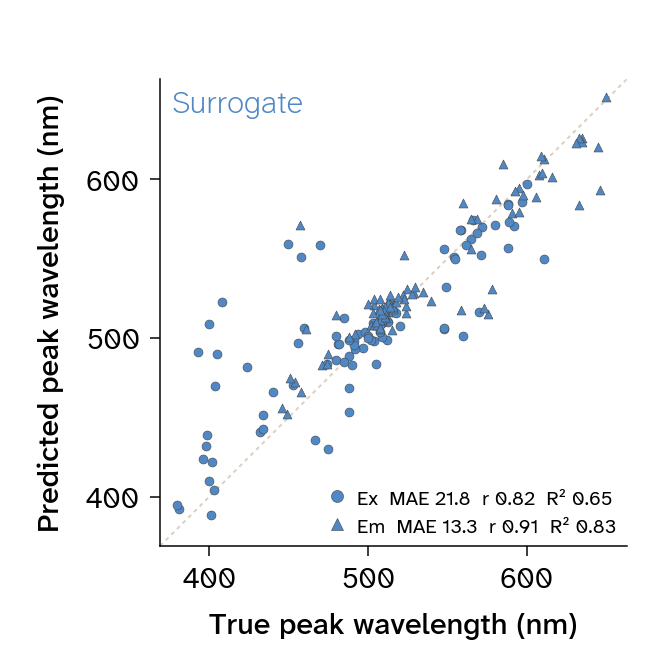

In [25]:
from matplotlib.lines import Line2D

EX_MARKER, EM_MARKER = "o", "^"


def plot_pred_scatter(name, m, color, fname):
    """True-vs-predicted peak wavelength for one model's test split. Excitation/emission are
    distinct marker shapes in the model's own colour; the legend carries MAE/r/R2 per peak,
    since the sweep's own selection metric (val MAE) averages over both and can hide a gap
    between them.
    """
    fig, ax = plt.subplots(figsize=(FULL_WIDE / 3 * PX, FULL_WIDE / 3 * PX))
    fig.subplots_adjust(left=0.24, right=0.94, bottom=0.18, top=0.88)

    lo, hi = min(m["P"].min(), m["T"].min()), max(m["P"].max(), m["T"].max())
    pad = 0.04 * (hi - lo)
    lim = (lo - pad, hi + pad)
    ax.plot(lim, lim, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=1, zorder=1)
    ax.scatter(m["T"][:, 0], m["P"][:, 0], s=20, marker=EX_MARKER, color=color,
               ec=str(apc.charcoal), linewidths=0.3, alpha=1, zorder=2)
    ax.scatter(m["T"][:, 1], m["P"][:, 1], s=20, marker=EM_MARKER, color=color,
               ec=str(apc.charcoal), linewidths=0.3, alpha=1, zorder=2)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_box_aspect(1)
    ax.set_xticks([400,500,600])
    ax.set_yticks([400,500,600])
    ax.set_xlabel("True peak wavelength (nm)"); ax.set_ylabel("Predicted peak wavelength (nm)")

    # Identity + config labelled in place (top-left, model colour) rather than an axes title --
    # in-figure titles are the caption's job per the guide.
    ax.annotate(f"{name}", xy=(0, 1), xycoords="axes fraction",
                xytext=(6, -6), textcoords="offset points", ha="left", va="top",
                **{**ANNOTATION, "fontsize": 16, "color": color})

    handles = [
        Line2D([], [], marker=EX_MARKER, linestyle="none", markerfacecolor=color,
               markeredgecolor=str(apc.charcoal), markeredgewidth=0.3,
               label=f"Ex  MAE {m['ex']['mae']:.1f}  r {m['ex']['r']:.2f}  R² {m['ex']['r2']:.2f}"),
        Line2D([], [], marker=EM_MARKER, linestyle="none", markerfacecolor=color,
               markeredgecolor=str(apc.charcoal), markeredgewidth=0.3,
               label=f"Em  MAE {m['em']['mae']:.1f}  r {m['em']['r']:.2f}  R² {m['em']['r2']:.2f}"),
    ]
    # style_plot auto-detects any legend on the axes and calls the buggy style_legend() (stray
    # rule-under-title line, see notebook conventions) -- style the plot BEFORE adding the legend,
    # then style the legend by hand with the same two safe helpers style_legend uses.
    apc.mpl.style_plot(ax, monospaced_axes="both")
    leg = ax.legend(handles=handles, loc="lower right", fontsize=10, frameon=True,
                    handletextpad=0.5, borderpad=0.5, labelspacing=0.4)
    leg.get_frame().set_edgecolor("none"); leg.get_frame().set_alpha(0.85)
    apc.mpl.capitalize_legend_text(leg)
    apc.mpl.justify_legend_text(leg)

    fig.savefig(f"{FIGDIR}/{fname}.svg")
    fig.savefig(f"{FIGDIR}/{fname}.png", dpi=200)
    plt.show()


plot_pred_scatter("Surrogate", surr_test, HIGHLIGHT, "peak_surrogate_test_predictions")

**Figure 6. The deployed surrogate's held-out test predictions track the true peak reasonably
well, but excitation lags emission by 8.6 nm of MAE.** Predicted vs. true peak wavelength for CNN
(1) - max (ESM-2), refit on the full surrogate train+val pool (515 proteins) and evaluated once on
its 91-protein test split (untouched throughout CV, training, and refitting): excitation MAE 21.8
nm / r 0.82 / R² 0.65 vs. emission MAE 13.3 nm / r 0.91 / R² 0.83 (pooled 17.6 nm). That pooled
figure is slightly better than the three CV fold-models' own average on this same 91-row test set
(18.8 nm, Figure 4) — consistent with training on the full 515-row pool rather than two-thirds of
it per fold. The excitation/emission gap Figure 1 already flagged as a property of the landscape
itself shows up again here. Figure 7 is the oracle's own equivalent, on its own independent test
split.

## 7. Test-set predictions: the oracle

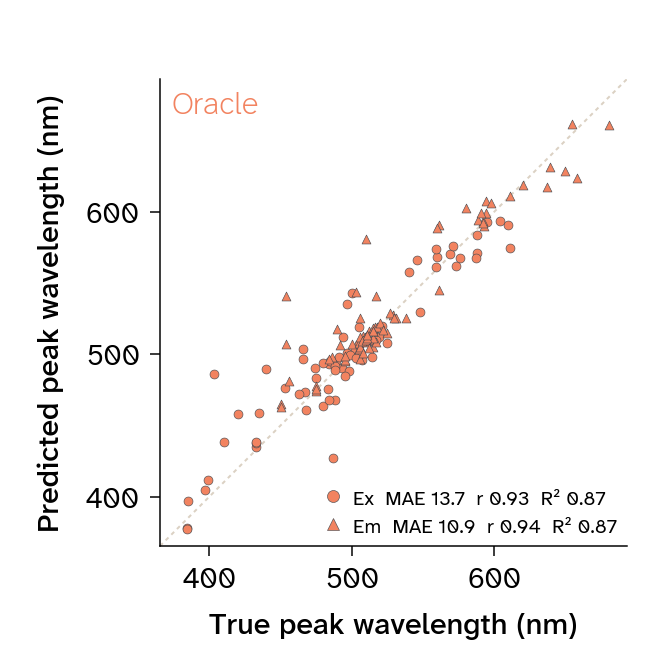

In [26]:
plot_pred_scatter("Oracle", oracle_test, CONTRAST, "peak_oracle_test_predictions")

**Figure 7. The oracle is better calibrated than the surrogate, and the excitation/emission gap
nearly closes.** Predicted vs. true peak wavelength for CNN (1) - max (ProstT5), the oracle
sweep's validation-selected winner (Figure 5), run once on its own 76-protein test split:
excitation MAE 13.7 nm / r 0.93 / R² 0.87 vs. emission MAE 10.9 nm / r 0.94 / R² 0.87 (pooled 12.3
nm) — both peaks land close together, unlike the surrogate's wider split in Figure 6. This mirrors
the oracle's own architecture sweep (Figure 5) beating its strongest null by a wider margin than
the surrogate's sweep did (8.0 nm vs. 4.7 nm, Figure 4) — a different pretrained encoder and a
different (nested) split, but consistently the stronger model of the two.